In [1]:
# =========================================================
# COMMON CODE FOR HORSE AUCTION PRICE PREDICTION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pygam import LinearGAM, s, f, te
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("="*70)
print("GAM MODEL FOR HORSE PRICE PREDICTION")
print("="*70)


# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def find_col(df, candidates):
    """Find column by exact, case-insensitive, or substring match."""
    cols = list(df.columns)
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_numeric_safe(series):
    """Convert series to numeric, handling various formats."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )



# ---------------------------------------------------------
# Load and prepare data
# ---------------------------------------------------------
print("="*70)
print("DATA PREPARATION")
print("="*70)

df = pd.read_excel("GAM.xlsx")
df.columns = [c.strip() for c in df.columns]
print(f"\nLoaded {len(df)} rows")

# Identify columns
col_price = find_col(df, ["Sales Price", "Hammer Price", "Price"])
col_studfee = find_col(df, ["Sire Stud Fee", "Stud Fee"])
col_dam_earnings = find_col(df, ["Dam Earnings"])
col_dam_best = find_col(df, ["Dam Best Time", "Dam Best"])
col_dam_starts = find_col(df, ["Dam Starts"])
col_dam_1st = find_col(df, ["Dam 1st"])
col_dam_age = find_col(df, ["Dam Age"])
col_age = find_col(df, ["Age in days", "Age"])
col_year = find_col(df, ["Year", "Auction Year"])
col_gender = find_col(df, ["Gender", "Sex"])
col_auction = find_col(df, ["Auction", "Auction House"])
col_siblings_raceage = find_col(df, ["Siblings Raceage"])
col_american_stakes = "American Stakes"  
col_surgery_report = "Surgery Certificate"
col_surgery_severity = "Surgery Severity"
col_xray_status = 'OCD_XRAY'
col_xray_remains = 'Xray_REM'
col_breeder = 'Breeder'
col_sire_first_season = find_col(df, ["First_Season_Flag"])
col_sire_starts = find_col(df, ["Sire Starts"])
col_sire_earnings = find_col(df, ["Sire Earnings"]) 
col_sire_1st = find_col(df, ["Sire 1st"])
col_dam_sire = find_col(df, ["Dams_Sire"])



# BLUP columns
col_dam_blup = find_col(df, ["Dam BLUP", "Dam_BLUP", "DamBLUP"])
col_sire_blup = find_col(df, ["Sire BLUP", "Sire_BLUP", "SireBLUP"])
col_dam_sire_blup = find_col(df, ["Dam Sire BLUP", "Dam_Sire_BLUP", "DamSireBLUP", "Damsire BLUP"])

print(f"\n[BLUP COLUMNS FOUND]")
print(f"  Dam BLUP:      {col_dam_blup}")
print(f"  Sire BLUP:     {col_sire_blup}")
print(f"  Dam Sire BLUP: {col_dam_sire_blup}")



# ---------------------------------------------------------
# Convert columns to numeric
# ---------------------------------------------------------
print("\n[CONVERTING COLUMNS TO NUMERIC]")
numeric_candidates = [
    col_price, col_studfee, col_dam_earnings, col_dam_best, 
    col_dam_starts, col_dam_1st, col_dam_age, col_age, col_siblings_raceage,
    "French Blood", "Inbreeding", "Sibling Earnings", "Sibling Starts",
    "Sibling 1st", "Gdam  Earnings", "Gdam Raceage", "Gdam Offspring 1st",
    "Gdam Offspring Starts", "Ggdam Earnings", "Ggdam Raceage",
    "Ggdam Offspring 1st", "Ggdam Offspring Starts",
    col_dam_blup, col_sire_blup, col_dam_sire_blup,
    col_surgery_report, col_surgery_severity, col_xray_remains,
    col_american_stakes, col_sire_starts, col_sire_earnings, col_sire_1st
]

for col in numeric_candidates:
    if col and col in df.columns:
        if df[col].dtype == 'object':
            print(f"  Converting: {col}")
        df[col] = to_numeric_safe(df[col])

# Target variable
df["log_price"] = np.log(df[col_price])

#Log transform stud fee

df["log_stud_fee"] = np.log(df[col_studfee])



# ---------------------------------------------------------
# Feature Engineering
# ---------------------------------------------------------
print("\n[FEATURE ENGINEERING]")


# Only calculate if dam has raced
df["DamWinPct"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_1st] / df[col_dam_starts],
    np.nan  
)

# Binary indicator for dam never raced
df["Dam_Never_Raced"] = (df[col_dam_starts].isna() | (df[col_dam_starts] == 0)).astype(int)


# Dam earnings pr start 
df["DamEarningsPerStart"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_earnings] / df[col_dam_starts],
    np.nan
)

# Sibling performance - KEEP NaN for missing
df["SiblingEarningsPerStart"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling Earnings"] / df["Sibling Starts"],
    np.nan
)

df["SiblingEarningsPerHorse"] = np.where(
    df[col_siblings_raceage] > 0,
    df["Sibling Earnings"] / df[col_siblings_raceage],
    np.nan
)

df["SiblingWinPct"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling 1st"] / df["Sibling Starts"],
    np.nan
)

# Binary indicator for no siblings
df["Siblings_Missing"] = (df[col_siblings_raceage].isna() | (df[col_siblings_raceage] == 0)).astype(int)

# Granddam performance
df["GranddamEarningsPerHorse"] = np.where(
    df["Gdam Raceage"] > 0,
    df["Gdam  Earnings"] / df["Gdam Raceage"],
    np.nan
)

df["GranddamWinPct"] = np.where(
    df["Gdam Offspring Starts"] > 0,
    df["Gdam Offspring 1st"] / df["Gdam Offspring Starts"],
    np.nan
)

# Great-granddam performance
df["GD_Dam_EarningsPerHorse"] = np.where(
    df["Ggdam Raceage"] > 0,
    df["Ggdam Earnings"] / df["Ggdam Raceage"],
    np.nan
)

df["GD_Dam_WinPct"] = np.where(
    df["Ggdam Offspring Starts"] > 0,
    df["Ggdam Offspring 1st"] / df["Ggdam Offspring Starts"],
    np.nan
)

# Sire performance

df["SireWinPct"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_1st] / df[col_sire_starts],
    np.nan
)

df["SireEarningsPerStart"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_earnings] / df[col_sire_starts],
    np.nan
)

#Inverse dam time so that sign is interpretable 
df['dam_time_inverse'] = 1 / df['Dam Best Time']

# Prize money impact 
prize_money_sek = {
    2023: 1.0,
    2024: 1.02,
    2025: 1.1
}

df["Log_Prize_Money"] = np.log(df[col_year].map(prize_money_sek))


# BLUP missing indicators
if col_dam_blup and col_dam_blup in df.columns:
    df["Dam_BLUP_Missing"] = df[col_dam_blup].isna().astype(int)
if col_sire_blup and col_sire_blup in df.columns:
    df["Sire_BLUP_Missing"] = df[col_sire_blup].isna().astype(int)
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    df["Dam_Sire_BLUP_Missing"] = df[col_dam_sire_blup].isna().astype(int)

# Categorical encoding
df[col_auction] = df[col_auction].astype(str).str.strip().str.upper()
df["Selective_Auctions"] = df[col_auction].isin(["EY", "SY"]).astype(int)

df[col_gender] = df[col_gender].astype(str).str.strip().str.upper()
df["Gender"] = (df[col_gender] == "H").astype(int)


# ---------------------------------------------------------
# XRAY_RISK_SCORE (deterministic feature)
# ---------------------------------------------------------
print("  Creating XRAY_RISK_SCORE")

# Ensure numeric types (in case they come in as object)
for c in [col_xray_status, col_surgery_report, col_surgery_severity, col_xray_remains]:
    if c in df.columns:
        df[c] = to_numeric_safe(df[c])

# Normalize: SURGERY_SEVERITY should be NaN when no surgery certificate
# (so '0' doesn't carry meaning beyond "not applicable")
if col_surgery_report in df.columns and col_surgery_severity in df.columns:
    df.loc[df[col_surgery_report] == 0, col_surgery_severity] = np.nan

# Compute score components (monotone, clamped to [0,1])
base_risk = np.where(df[col_xray_status] == 1, 0.40, 0.00)
surgery_mitigation = np.where(df[col_surgery_report] == 1, -0.10, 0.00)

# disease burden: only if severity exists (3-5). If NaN -> 0.0
# disease burden (severity)

severity_map = {
    3: 0.10,
    4: 0.30,
    5: 0.60
}

severity_risk = df[col_surgery_severity].map(severity_map).fillna(0.0)



# residual risk: X_RAY_REM assumed 0-3; if missing -> 0 (or NaN if you prefer)
rem = df[col_xray_remains].fillna(0.0)
residual_risk = 0.15 * rem

df["XRAY_RISK_SCORE"] = base_risk + surgery_mitigation + severity_risk + residual_risk
df["XRAY_RISK_SCORE"] = df["XRAY_RISK_SCORE"].clip(lower=0.0, upper=1.0)


print("  Created derived features")


df.to_excel("GAM_ENGINEERED.xlsx", index=True)




GAM MODEL FOR HORSE PRICE PREDICTION
DATA PREPARATION

Loaded 1618 rows

[BLUP COLUMNS FOUND]
  Dam BLUP:      Dam BLUP
  Sire BLUP:     Sire BLUP
  Dam Sire BLUP: Dam Sire BLUP

[CONVERTING COLUMNS TO NUMERIC]
  Converting: French Blood
  Converting: Inbreeding

[FEATURE ENGINEERING]
  Creating XRAY_RISK_SCORE
  Created derived features


In [3]:
# ---------------------------------------------------------
# Train/Test Split
# ---------------------------------------------------------
TRAIN_YEARS = [2023, 2024]
TEST_YEAR = 2025

train_mask = df[col_year].isin(TRAIN_YEARS)
test_mask = df[col_year] == TEST_YEAR

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

y_train = df_train["log_price"].copy()
y_test = df_test["log_price"].copy()

print(f"[SPLIT]")
print(f"  Train: {len(df_train)} rows ({TRAIN_YEARS})")
print(f"  Test: {len(df_test)} rows ({TEST_YEAR})")

[SPLIT]
  Train: 1108 rows ([2023, 2024])
  Test: 510 rows (2025)


In [5]:
# =========================================================
# BREEDER - SMOOTHED TARGET ENCODING (with LOO for training)
# =========================================================

print("="*70)
print("BREEDER - SMOOTHED TARGET ENCODING")
print("="*70)

# ---------------------------------------------------------
# 1. Calculate breeder statistics on TRAINING DATA
# ---------------------------------------------------------
target = 'log_price'

# Global mean from training data
global_mean_breeder = df_train[target].mean()

# Breeder-level statistics from training data
breeder_stats = df_train.groupby(col_breeder)[target].agg(['sum', 'count', 'std'])
breeder_stats.columns = ['breeder_sum', 'n', 'breeder_std']
breeder_stats['breeder_mean'] = breeder_stats['breeder_sum'] / breeder_stats['n']

print(f"\n[BREEDER STATISTICS (from training data)]")
print(f"  Unique breeders in train: {len(breeder_stats)}")
print(f"  Global mean (log_price):  {global_mean_breeder:.4f}")
print(f"\n  Breeder count distribution:")
print(f"    1 horse:     {(breeder_stats['n'] == 1).sum()} breeders")
print(f"    2-5 horses:  {((breeder_stats['n'] >= 2) & (breeder_stats['n'] <= 5)).sum()} breeders")
print(f"    6-10 horses: {((breeder_stats['n'] >= 6) & (breeder_stats['n'] <= 10)).sum()} breeders")
print(f"    11+ horses:  {(breeder_stats['n'] > 10).sum()} breeders")


# Calculate smoothing parameter (Empirical Bayes)

global_var = df_train[target].var()
within_var = breeder_stats['breeder_std'].mean() ** 2



m_breeder = global_var / within_var if within_var > 0 else 5

print(f"\n[SMOOTHING PARAMETER]")
print(f"  Empirical Bayes m: {m_breeder:.2f}")

# ---------------------------------------------------------
# 3. TRAINING DATA: Leave-One-Out Encoding
# ---------------------------------------------------------
# For each training horse: exclude its own price from breeder mean

# Map breeder totals to each row
train_breeder_sum = df_train[col_breeder].map(breeder_stats['breeder_sum'])
train_breeder_n = df_train[col_breeder].map(breeder_stats['n'])

# LOO mean: (sum - this_horse_price) / (n - 1)
loo_mean = (train_breeder_sum - df_train[target]) / (train_breeder_n - 1)

# For single-horse breeders, LOO mean is undefined → use global mean
loo_mean = loo_mean.fillna(global_mean_breeder)

# Effective sample size for smoothing
loo_n = (train_breeder_n - 1).clip(lower=0)

# Apply smoothing to LOO means
df_train['Breeder_Encoded'] = (loo_n * loo_mean + m_breeder * global_mean_breeder) / (loo_n + m_breeder)
df_train['Breeder_Encoded'] = df_train['Breeder_Encoded'].fillna(global_mean_breeder)

print(f"\n[TRAINING DATA: Leave-One-Out Encoding Applied]")
print(f"  Each horse's encoding excludes its own price")

# ---------------------------------------------------------
# 4. TEST DATA: Standard Encoding (use full training stats)
# ---------------------------------------------------------
# Test horses were never in training, so no LOO needed

def smoothed_target_encode(df, col, stats, global_mean, m):
    """Apply smoothed target encoding using full breeder stats."""
    n = df[col].map(stats['n']).fillna(0)
    breeder_mean = df[col].map(stats['breeder_mean']).fillna(global_mean)
    encoded = (n * breeder_mean + m * global_mean) / (n + m)
    return encoded.fillna(global_mean)

df_test['Breeder_Encoded'] = smoothed_target_encode(
    df_test, col_breeder, breeder_stats, global_mean_breeder, m_breeder
)

# Check for new breeders in test set
train_breeders = set(df_train[col_breeder].unique())
test_breeders = set(df_test[col_breeder].unique())
new_breeders = test_breeders - train_breeders

print(f"\n[TEST DATA: Standard Encoding Applied]")
print(f"  Uses full training breeder statistics")
print(f"  New breeders in test: {len(new_breeders)} (will use global mean)")

# ---------------------------------------------------------
# 5. Summary statistics
# ---------------------------------------------------------
print(f"\n[ENCODED FEATURE STATISTICS]")
print(f"  Train - Mean: {df_train['Breeder_Encoded'].mean():.4f}, Std: {df_train['Breeder_Encoded'].std():.4f}")
print(f"  Test  - Mean: {df_test['Breeder_Encoded'].mean():.4f}, Std: {df_test['Breeder_Encoded'].std():.4f}")

# ---------------------------------------------------------
# 6. Correlation check
# ---------------------------------------------------------
corr_train = df_train['Breeder_Encoded'].corr(df_train['log_price'])
corr_test = df_test['Breeder_Encoded'].corr(df_test['log_price'])

print(f"\n[CORRELATION WITH log_price]")
print(f"  Train (LOO): r = {corr_train:+.4f}  ← No leakage")
print(f"  Test:        r = {corr_test:+.4f}  ← Out-of-sample")


BREEDER - SMOOTHED TARGET ENCODING

[BREEDER STATISTICS (from training data)]
  Unique breeders in train: 309
  Global mean (log_price):  11.7590

  Breeder count distribution:
    1 horse:     147 breeders
    2-5 horses:  119 breeders
    6-10 horses: 26 breeders
    11+ horses:  17 breeders

[SMOOTHING PARAMETER]
  Empirical Bayes m: 2.22

[TRAINING DATA: Leave-One-Out Encoding Applied]
  Each horse's encoding excludes its own price

[TEST DATA: Standard Encoding Applied]
  Uses full training breeder statistics
  New breeders in test: 61 (will use global mean)

[ENCODED FEATURE STATISTICS]
  Train - Mean: 11.7896, Std: 0.4040
  Test  - Mean: 11.8670, Std: 0.3974

[CORRELATION WITH log_price]
  Train (LOO): r = +0.4021  ← No leakage
  Test:        r = +0.2988  ← Out-of-sample


In [7]:
# ---------------------------------------------------------
# Define feature types for GAM
# ---------------------------------------------------------

# Smooth terms (continuous features)
smooth_features = [
    'French Blood',
    'Inbreeding',
    col_age,
    'log_stud_fee',
   # 'SireWinPct',
    'SireEarningsPerStart',
    # col_dam_best,
    'dam_time_inverse',
    'DamWinPct',
    'DamEarningsPerStart',
    col_dam_age,
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    'SiblingEarningsPerHorse',
    'SiblingWinPct',
    'GranddamEarningsPerHorse',
    'GranddamWinPct',
    'GD_Dam_EarningsPerHorse',
    'GD_Dam_WinPct',
    'XRAY_RISK_SCORE',
    'Breeder_Encoded',  
 
]

# Linear/factor terms (binary indicators)
linear_features = [
    'Gender',
    'Selective_Auctions',
    'Dam_Never_Raced',
    'Siblings_Missing',
    'Dam_BLUP_Missing',
    'Sire_BLUP_Missing', 
    'Dam_Sire_BLUP_Missing',
    col_american_stakes,
    col_sire_first_season,
#    'Log_Prize_Money',
]

# Filter to existing columns (check df_train, not df!)
smooth_features = [f for f in smooth_features if f and f in df_train.columns]
linear_features = [f for f in linear_features if f and f in df_train.columns]

print(f"[GAM FEATURES]")
print(f"  Smooth terms (s): {len(smooth_features)}")
for f in smooth_features:
    print(f"    - {f}")
print(f"  Linear terms (l): {len(linear_features)}")
for f in linear_features:
    print(f"    - {f}")

# ---------------------------------------------------------
# Combine into FEATURES list
# ---------------------------------------------------------
FEATURES = smooth_features + linear_features

print(f"\n[TOTAL FEATURES]: {len(FEATURES)}")

# ---------------------------------------------------------
# Create feature matrices
# ---------------------------------------------------------
X_train_raw = df_train[FEATURES].copy()
X_test_raw = df_test[FEATURES].copy()

# Convert any remaining object columns
for col in X_train_raw.columns:
    if X_train_raw[col].dtype == 'object':
        print(f"  Converting {col} to numeric")
        X_train_raw[col] = pd.to_numeric(X_train_raw[col], errors='coerce')
        X_test_raw[col] = pd.to_numeric(X_test_raw[col], errors='coerce')

# Handle infinities
X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan)
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)

print(f"\n[FEATURE MATRICES]")
print(f"  X_train_raw: {X_train_raw.shape}")
print(f"  X_test_raw:  {X_test_raw.shape}")

[GAM FEATURES]
  Smooth terms (s): 20
    - French Blood
    - Inbreeding
    - Age in days
    - log_stud_fee
    - SireEarningsPerStart
    - dam_time_inverse
    - DamWinPct
    - DamEarningsPerStart
    - Dam Age
    - Dam BLUP
    - Sire BLUP
    - Dam Sire BLUP
    - SiblingEarningsPerHorse
    - SiblingWinPct
    - GranddamEarningsPerHorse
    - GranddamWinPct
    - GD_Dam_EarningsPerHorse
    - GD_Dam_WinPct
    - XRAY_RISK_SCORE
    - Breeder_Encoded
  Linear terms (l): 9
    - Gender
    - Selective_Auctions
    - Dam_Never_Raced
    - Siblings_Missing
    - Dam_BLUP_Missing
    - Sire_BLUP_Missing
    - Dam_Sire_BLUP_Missing
    - American Stakes
    - First_Season_Flag

[TOTAL FEATURES]: 29

[FEATURE MATRICES]
  X_train_raw: (1108, 29)
  X_test_raw:  (510, 29)


In [9]:
# =========================================================
# SMART MISSING VALUE IMPUTATION
# =========================================================

print("="*70)
print("SMART MISSING VALUE IMPUTATION")
print("="*70)

# ---------------------------------------------------------
# 1. Informative missingness: Impute with 0
# ---------------------------------------------------------
print("\n[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]")

zero_impute_cols = [
    'SiblingEarningsPerHorse',
    'SiblingEarningsPerStart', 
    'SiblingWinPct',
    'dam_time_inverse',
    'DamEarningsPerStart',
    'DamWinPct',
]

for col in zero_impute_cols:
    if col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        X_train_raw[col] = X_train_raw[col].fillna(0)
        X_test_raw[col] = X_test_raw[col].fillna(0)
        print(f"  {col}: {n_missing} → filled with 0")

# ---------------------------------------------------------
# 2. Regular missingness: Impute with median
# ---------------------------------------------------------
print("\n[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]")

median_impute_cols = [
    'GranddamEarningsPerHorse',
    'GranddamWinPct',
    'GD_Dam_EarningsPerHorse',
    'GD_Dam_WinPct',
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    'XRAY_RISK_SCORE',
]

for col in median_impute_cols:
    if col and col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        if n_missing > 0:
            median_val = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(median_val)
            X_test_raw[col] = X_test_raw[col].fillna(median_val)
            print(f"  {col}: {n_missing} → filled with median ({median_val:.2f})")

# ---------------------------------------------------------
# 3. Final check
# ---------------------------------------------------------
print(f"\n[VERIFICATION]")
print(f"  X_train NaN remaining: {X_train_raw.isna().sum().sum()}")
print(f"  X_test NaN remaining:  {X_test_raw.isna().sum().sum()}")

# Now create X_train, X_test
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()


X_train.to_excel("X_train_imputed.xlsx", index=True)
X_test.to_excel("X_test_imputed.xlsx", index=True)

SMART MISSING VALUE IMPUTATION

[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]
  SiblingEarningsPerHorse: 331 → filled with 0
  SiblingWinPct: 450 → filled with 0
  dam_time_inverse: 150 → filled with 0
  DamEarningsPerStart: 158 → filled with 0
  DamWinPct: 152 → filled with 0

[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]
  GranddamEarningsPerHorse: 49 → filled with median (741201.67)
  GranddamWinPct: 53 → filled with median (0.16)
  GD_Dam_EarningsPerHorse: 35 → filled with median (886150.50)
  GD_Dam_WinPct: 41 → filled with median (0.16)
  Dam BLUP: 229 → filled with median (107.00)
  Sire BLUP: 156 → filled with median (118.00)
  Dam Sire BLUP: 46 → filled with median (110.00)

[VERIFICATION]
  X_train NaN remaining: 0
  X_test NaN remaining:  0


In [10]:
# =========================================================
# GAM MODEL CONFIGURATION AND TRAINING
# =========================================================

print("="*70)
print("GAM MODEL")
print("="*70)

print(f"\n[GAM FORMULA CONSTRUCTION]")
print(f"  Splines (s) for continuous features")
print(f"  Factors (f) for categorical/binary features")

# --- Gate dam_time_inverse so the smooth only applies when dam has raced ---
idx_time = FEATURES.index("dam_time_inverse")
idx_never = FEATURES.index("Dam_Never_Raced")

X_train_gam = X_train.copy()
X_test_gam  = X_test.copy()

X_train_gam.iloc[:, idx_time] = X_train_gam.iloc[:, idx_time] * (1 - X_train_gam.iloc[:, idx_never])
X_test_gam.iloc[:, idx_time]  = X_test_gam.iloc[:, idx_time]  * (1 - X_test_gam.iloc[:, idx_never])

# Build GAM terms
from pygam import s as gam_s, f as gam_f

gam_terms = None
for i, feat in enumerate(FEATURES):
    if feat in linear_features:  # <-- Use linear_features
        term = gam_f(i)
        print(f"  Feature {i}: {feat} → f({i}) [categorical/binary]")
    else:
        term = gam_s(i, n_splines=10)
        print(f"  Feature {i}: {feat} → s({i}) [smooth spline]")
    
    if gam_terms is None:
        gam_terms = term
    else:
        gam_terms = gam_terms + term

# ---------------------------------------------------------
# Train GAM model
# ---------------------------------------------------------
print(f"\n[FITTING GAM]")
print(f"  Using gridsearch for optimal lambda...")

gam = LinearGAM(gam_terms)
#gam.gridsearch(X_train.values, y_train.values, lam=np.logspace(-3, 3, 11), progress=True)

gam.gridsearch(X_train_gam.values, y_train.values, lam=np.logspace(-3, 3, 11), progress=True)


print(f"\n✓ GAM training complete")
print(f"  Best lambda: {gam.lam}")

# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------
#red_train = gam.predict(X_train.values)
#pred_test = gam.predict(X_test.values)

pred_train = gam.predict(X_train_gam.values)
pred_test = gam.predict(X_test_gam.values)

# Calculate sigma² for log-bias correction
sigma2 = np.var(y_train.values - pred_train)

# ---------------------------------------------------------
# LOG SCALE METRICS
# ---------------------------------------------------------
train_r2_log = r2_score(y_train, pred_train)
test_r2_log = r2_score(y_test, pred_test)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_test))
mae_log = mean_absolute_error(y_test, pred_test)
mape_log = np.mean(np.abs((y_test.values - pred_test) / y_test.values)) * 100
mdape_log = np.median(np.abs((y_test.values - pred_test) / y_test.values)) * 100

print(f"\n[LOG SCALE METRICS]")
print(f"  Train R²:  {train_r2_log:.4f}")
print(f"  Test R²:   {test_r2_log:.4f}")
print(f"  Gap:       {train_r2_log - test_r2_log:.4f}")
print(f"  RMSE:      {rmse_log:.4f}")
print(f"  MAE:       {mae_log:.4f}")
print(f"  MAPE:      {mape_log:.2f}%")
print(f"  MdAPE:     {mdape_log:.2f}%")

# ---------------------------------------------------------
# PRICE SCALE METRICS
# ---------------------------------------------------------
y_train_price = np.exp(y_train.values)
y_test_price = np.exp(y_test.values)
pred_train_price = np.exp(pred_train + sigma2/2)
pred_test_price = np.exp(pred_test + sigma2/2)

test_r2_price = r2_score(y_test_price, pred_test_price)
rmse_price = np.sqrt(mean_squared_error(y_test_price, pred_test_price))
mae_price = mean_absolute_error(y_test_price, pred_test_price)
mean_error = np.mean(pred_test_price - y_test_price)
median_error = np.median(pred_test_price - y_test_price)
mape_price = np.mean(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100
mdape_price = np.median(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100

print(f"\n[PRICE SCALE METRICS (NOK)]")
print(f"  Test R²:       {test_r2_price:.4f}")
print(f"  RMSE:          {rmse_price:,.0f}")
print(f"  MAE:           {mae_price:,.0f}")
print(f"  Mean Error:    {mean_error:+,.0f}")
print(f"  Median Error:  {median_error:+,.0f}")
print(f"  MAPE:          {mape_price:.1f}%")
print(f"  MdAPE:         {mdape_price:.1f}%")

# Store results
gam_results = {
    'train_r2_log': train_r2_log,
    'test_r2_log': test_r2_log,
    'rmse_log': rmse_log,
    'mae_log': mae_log,
    'mape_log': mape_log,
    'mdape_log': mdape_log,
    'test_r2_price': test_r2_price,
    'rmse_price': rmse_price,
    'mae_price': mae_price,
    'mean_error': mean_error,
    'mape_price': mape_price,
    'mdape_price': mdape_price,
}

# Check overfitting
gap = train_r2_log - test_r2_log
if gap < 0.10:
    print(f"\n✓ Gap of {gap:.4f} indicates good generalization")
elif gap < 0.20:
    print(f"\n~ Gap of {gap:.4f} is acceptable")
else:
    print(f"\n⚠ Gap of {gap:.4f} suggests some overfitting")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

GAM MODEL

[GAM FORMULA CONSTRUCTION]
  Splines (s) for continuous features
  Factors (f) for categorical/binary features
  Feature 0: French Blood → s(0) [smooth spline]
  Feature 1: Inbreeding → s(1) [smooth spline]
  Feature 2: Age in days → s(2) [smooth spline]
  Feature 3: log_stud_fee → s(3) [smooth spline]
  Feature 4: SireEarningsPerStart → s(4) [smooth spline]
  Feature 5: dam_time_inverse → s(5) [smooth spline]
  Feature 6: DamWinPct → s(6) [smooth spline]
  Feature 7: DamEarningsPerStart → s(7) [smooth spline]
  Feature 8: Dam Age → s(8) [smooth spline]
  Feature 9: Dam BLUP → s(9) [smooth spline]
  Feature 10: Sire BLUP → s(10) [smooth spline]
  Feature 11: Dam Sire BLUP → s(11) [smooth spline]
  Feature 12: SiblingEarningsPerHorse → s(12) [smooth spline]
  Feature 13: SiblingWinPct → s(13) [smooth spline]
  Feature 14: GranddamEarningsPerHorse → s(14) [smooth spline]
  Feature 15: GranddamWinPct → s(15) [smooth spline]
  Feature 16: GD_Dam_EarningsPerHorse → s(16) [smooth 

100% (11 of 11) |########################| Elapsed Time: 0:00:15 Time:  0:00:150:01



✓ GAM training complete
  Best lambda: [[63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193]]

[LOG SCALE METRICS]
  Train R²:  0.6288
  Test R²:   0.4261
  Gap:       0.2028
  RMSE:      0.7552
  MAE:       0.6228
  MAPE:      5.22%
  MdAPE:     4.59%

[PRICE SCALE METRICS (NOK)]
  Test R²:       0.3159
  RMSE:          265,235
  MAE:           151,779
  Mean Error:    -15,085
  Median Error:  +18,587
  MAPE:          86.0%
  MdAPE:         53.4%

⚠ Gap of 0.2028 sugg

GAM: CROSS-VALIDATED METRICS & OOF SIGMA²

[CV SETUP]
  Strategy:  GroupKFold (group = Year)
  Folds:     2
  Fold 1:   Train on [2024] (539 rows) → Predict [2023] (569 rows)
  Fold 2:   Train on [2023] (569 rows) → Predict [2024] (539 rows)

──────────────────────────────────────────────────────────────────────
FOLD 1/2
──────────────────────────────────────────────────────────────────────
  Fitting GAM with gridsearch...
  Best lambda: [[63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193], [63.0957344480193

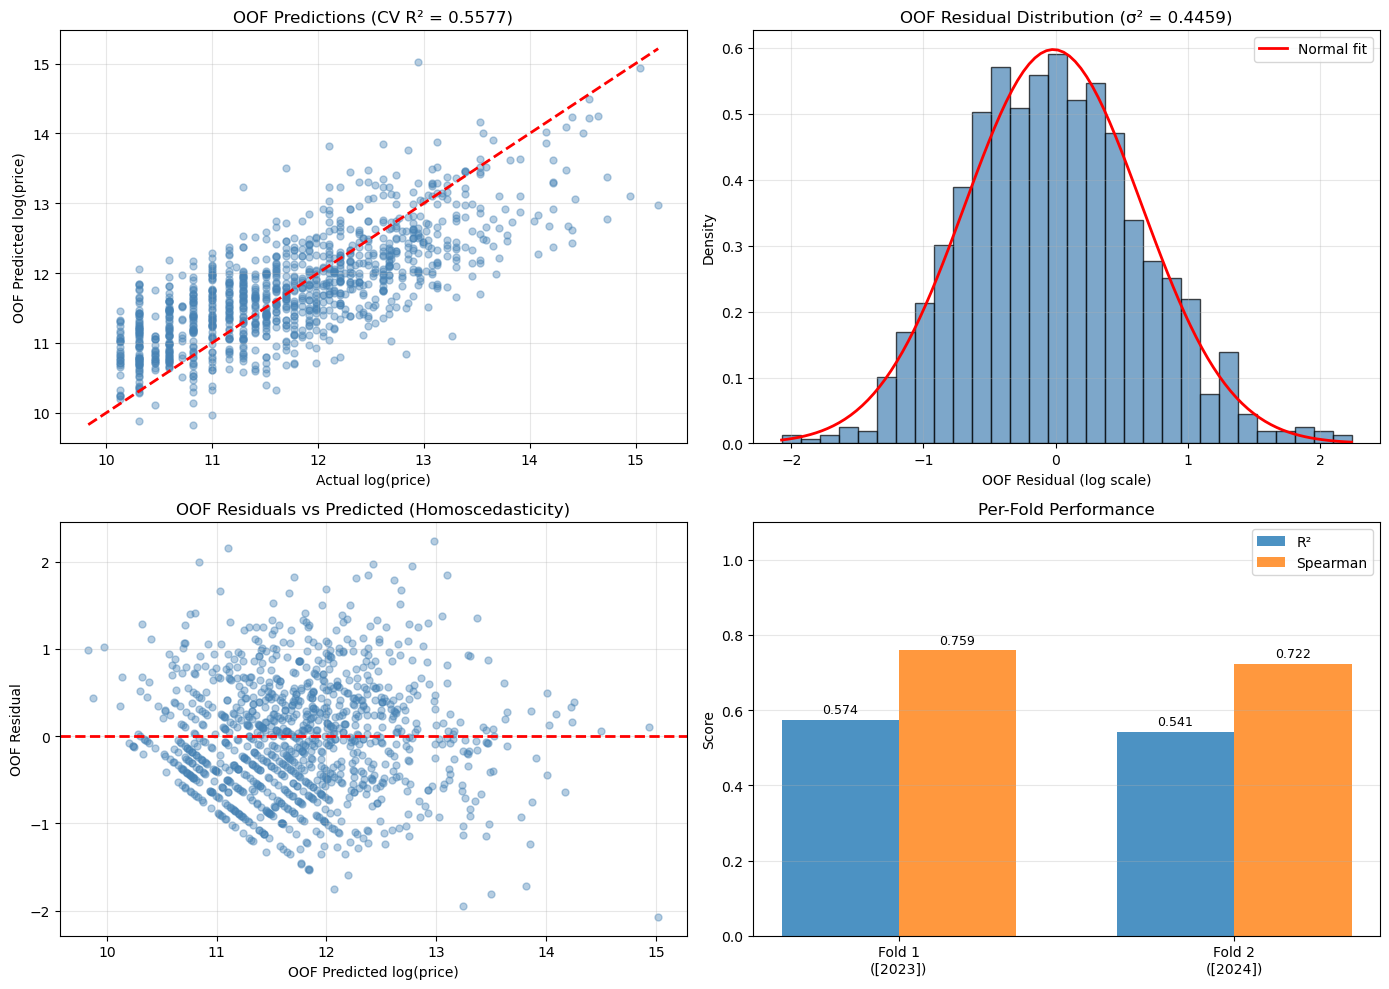


✓ Saved: gam_cv_oof_analysis.png

UPDATING SIGMA² FOR DOWNSTREAM CELLS
  sigma2 = 0.4459  (OOF estimate)
  exp(sigma2/2) = 1.2498

  pred_train_price and pred_test_price updated with OOF σ²
  All downstream cells will use this corrected value

TRAINING vs OOF vs TEST PERFORMANCE (LOG SCALE)

  Metric         Training          OOF         Test
  ---------- ------------ ------------ ------------
  R²               0.6288       0.5609       0.4261
  MAE              0.4930       0.5362       0.6228
  RMSE             0.6142       0.6680       0.7552

✓ Saved: gam_train_oof_test_log.xlsx

✓ Saved: gam_cv_metrics.xlsx
✓ Saved: gam_oof_predictions.xlsx

GAM CROSS-VALIDATION COMPLETE


In [12]:
# =========================================================
# GAM: CROSS-VALIDATED METRICS & OUT-OF-FOLD SIGMA²
# =========================================================
# Matches the GroupKFold(n_splits=2) approach used in
# XGBoost and Random Forest for consistent comparison.
#
# IMPORTANT: Unlike tree models, GAM CV requires redoing
# breeder encoding and imputation inside each fold to
# prevent data leakage.
#
# Place this cell AFTER the main GAM training cell (Cell 6)
# so that gam_terms, FEATURES, etc. are already defined.
# =========================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr
from pygam import LinearGAM

print("=" * 70)
print("GAM: CROSS-VALIDATED METRICS & OOF SIGMA²")
print("=" * 70)

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
N_SPLITS = 2  # 2 years → 2 folds (2023 vs 2024)
groups = df_train[col_year].values

cv = GroupKFold(n_splits=N_SPLITS)
folds = list(cv.split(df_train, y_train, groups=groups))

print(f"\n[CV SETUP]")
print(f"  Strategy:  GroupKFold (group = Year)")
print(f"  Folds:     {N_SPLITS}")
for fold_idx, (train_pos, val_pos) in enumerate(folds):
    fold_years_train = df_train.iloc[train_pos][col_year].unique()
    fold_years_val = df_train.iloc[val_pos][col_year].unique()
    print(f"  Fold {fold_idx+1}:   Train on {sorted(fold_years_train)} ({len(train_pos)} rows) "
          f"→ Predict {sorted(fold_years_val)} ({len(val_pos)} rows)")


# ---------------------------------------------------------
# Helper: Breeder LOO target encoding (per fold)
# ---------------------------------------------------------
def encode_breeder_fold(df_fold_train, df_fold_val, col_breeder, target):
    """
    Breeder target encoding with LOO for fold-train,
    standard smoothed encoding for fold-val.
    Mirrors the logic in Cell 3.
    """
    global_mean = df_fold_train[target].mean()

    # Breeder stats from fold training data
    stats = df_fold_train.groupby(col_breeder)[target].agg(["sum", "count", "std"])
    stats.columns = ["breeder_sum", "n", "breeder_std"]
    stats["breeder_mean"] = stats["breeder_sum"] / stats["n"]

    # Smoothing parameter (Empirical Bayes)
    global_var = df_fold_train[target].var()
    within_var = stats["breeder_std"].mean() ** 2
    m = global_var / within_var if within_var > 0 else 5

    # --- FOLD TRAIN: Leave-One-Out encoding ---
    train_sum = df_fold_train[col_breeder].map(stats["breeder_sum"])
    train_n = df_fold_train[col_breeder].map(stats["n"])
    loo_mean = (train_sum - df_fold_train[target]) / (train_n - 1)
    loo_mean = loo_mean.fillna(global_mean)
    loo_n = (train_n - 1).clip(lower=0)
    fold_train_encoded = (loo_n * loo_mean + m * global_mean) / (loo_n + m)
    fold_train_encoded = fold_train_encoded.fillna(global_mean)

    # --- FOLD VAL: Standard smoothed encoding ---
    val_n = df_fold_val[col_breeder].map(stats["n"]).fillna(0)
    val_mean = df_fold_val[col_breeder].map(stats["breeder_mean"]).fillna(global_mean)
    fold_val_encoded = (val_n * val_mean + m * global_mean) / (val_n + m)
    fold_val_encoded = fold_val_encoded.fillna(global_mean)

    return fold_train_encoded, fold_val_encoded


# ---------------------------------------------------------
# Helper: Smart imputation (per fold)
# ---------------------------------------------------------
def impute_fold(X_fold_train, X_fold_val, zero_cols, median_cols):
    """
    Apply zero-imputation and median-imputation using
    fold-train statistics only. Mirrors Cell 5.
    """
    X_tr = X_fold_train.copy()
    X_va = X_fold_val.copy()

    # Zero imputation (informative missingness)
    for col in zero_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna(0)
            X_va[col] = X_va[col].fillna(0)

    # Median imputation (from fold-train only)
    for col in median_cols:
        if col and col in X_tr.columns:
            n_miss = X_tr[col].isna().sum()
            if n_miss > 0:
                med = X_tr[col].median()
                X_tr[col] = X_tr[col].fillna(med)
                X_va[col] = X_va[col].fillna(med)

    return X_tr, X_va


# ---------------------------------------------------------
# Helper: Apply dam_time_inverse gating
# ---------------------------------------------------------
def gate_dam_time(X_df, features):
    """Zero out dam_time_inverse when Dam_Never_Raced == 1."""
    X = X_df.copy()
    idx_time = features.index("dam_time_inverse")
    idx_never = features.index("Dam_Never_Raced")
    X.iloc[:, idx_time] = X.iloc[:, idx_time] * (1 - X.iloc[:, idx_never])
    return X


# ---------------------------------------------------------
# Define imputation column lists (same as Cell 5)
# ---------------------------------------------------------
zero_impute_cols = [
    "SiblingEarningsPerHorse",
    "SiblingEarningsPerStart",
    "SiblingWinPct",
    "dam_time_inverse",
    "DamEarningsPerStart",
    "DamWinPct",
]

median_impute_cols = [
    "GranddamEarningsPerHorse",
    "GranddamWinPct",
    "GD_Dam_EarningsPerHorse",
    "GD_Dam_WinPct",
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    "XRAY_RISK_SCORE",
]


# =========================================================
# CROSS-VALIDATION LOOP
# =========================================================

oof_predictions = np.full(len(df_train), np.nan)
fold_metrics = []

for fold_idx, (train_pos, val_pos) in enumerate(folds):
    print(f"\n{'─' * 70}")
    print(f"FOLD {fold_idx + 1}/{N_SPLITS}")
    print(f"{'─' * 70}")

    # --- Split data ---
    df_f_train = df_train.iloc[train_pos].copy()
    df_f_val = df_train.iloc[val_pos].copy()
    y_f_train = y_train.iloc[train_pos].copy()
    y_f_val = y_train.iloc[val_pos].copy()

    # --- 1. Breeder encoding (per fold) ---
    df_f_train["Breeder_Encoded"], df_f_val["Breeder_Encoded"] = encode_breeder_fold(
        df_f_train, df_f_val, col_breeder, "log_price"
    )

    # --- 2. Build feature matrices ---
    X_f_train_raw = df_f_train[FEATURES].copy()
    X_f_val_raw = df_f_val[FEATURES].copy()

    # Handle infinities
    X_f_train_raw = X_f_train_raw.replace([np.inf, -np.inf], np.nan)
    X_f_val_raw = X_f_val_raw.replace([np.inf, -np.inf], np.nan)

    # --- 3. Imputation (per fold) ---
    X_f_train_imp, X_f_val_imp = impute_fold(
        X_f_train_raw, X_f_val_raw, zero_impute_cols, median_impute_cols
    )

    # --- 4. Dam time gating ---
    X_f_train_gam = gate_dam_time(X_f_train_imp, FEATURES)
    X_f_val_gam = gate_dam_time(X_f_val_imp, FEATURES)

    # --- 5. Verify no NaNs ---
    n_nan_train = X_f_train_gam.isna().sum().sum()
    n_nan_val = X_f_val_gam.isna().sum().sum()
    if n_nan_train > 0 or n_nan_val > 0:
        print(f"  ⚠ Remaining NaNs: train={n_nan_train}, val={n_nan_val}")
        # Fill any stragglers with 0
        X_f_train_gam = X_f_train_gam.fillna(0)
        X_f_val_gam = X_f_val_gam.fillna(0)

    # --- 6. Fit GAM ---
    print(f"  Fitting GAM with gridsearch...")
    fold_gam = LinearGAM(gam_terms)
    fold_gam.gridsearch(
        X_f_train_gam.values, y_f_train.values,
        lam=np.logspace(-3, 3, 11), progress=False
    )
    print(f"  Best lambda: {fold_gam.lam}")

    # --- 7. Predict on validation fold ---
    fold_pred = fold_gam.predict(X_f_val_gam.values)
    oof_predictions[val_pos] = fold_pred

    # --- 8. Fold metrics (log scale) ---
    fold_r2 = r2_score(y_f_val, fold_pred)
    fold_rmse = np.sqrt(mean_squared_error(y_f_val, fold_pred))
    fold_mae = mean_absolute_error(y_f_val, fold_pred)
    fold_mape = np.mean(np.abs((y_f_val.values - fold_pred) / y_f_val.values)) * 100
    fold_mdape = np.median(np.abs((y_f_val.values - fold_pred) / y_f_val.values)) * 100

    # Rank correlation
    fold_spearman, _ = spearmanr(y_f_val.values, fold_pred)

    fold_years_val = sorted(df_f_val[col_year].unique())
    fold_metrics.append({
        "Fold": fold_idx + 1,
        "Val_Years": str(fold_years_val),
        "N_train": len(train_pos),
        "N_val": len(val_pos),
        "R²": fold_r2,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "MAPE": fold_mape,
        "MdAPE": fold_mdape,
        "Spearman": fold_spearman,
    })

    print(f"\n  [FOLD {fold_idx+1} RESULTS — Log Scale]")
    print(f"    R²:       {fold_r2:.4f}")
    print(f"    RMSE:     {fold_rmse:.4f}")
    print(f"    MAE:      {fold_mae:.4f}")
    print(f"    MAPE:     {fold_mape:.2f}%")
    print(f"    MdAPE:    {fold_mdape:.2f}%")
    print(f"    Spearman: {fold_spearman:.4f}")


# =========================================================
# AGGREGATE CV RESULTS
# =========================================================

print(f"\n{'=' * 70}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'=' * 70}")

metrics_df = pd.DataFrame(fold_metrics)

print(f"\n[PER-FOLD RESULTS]")
print(metrics_df.to_string(index=False, float_format="%.4f"))

# Weighted average (by validation set size)
weights = metrics_df["N_val"].values
total_n = weights.sum()

print(f"\n[AGGREGATED CV METRICS — Log Scale]")
print(f"  {'Metric':<12} {'Mean':>10} {'Std':>10} {'Weighted Mean':>15}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*15}")

for metric in ["R²", "RMSE", "MAE", "MAPE", "MdAPE", "Spearman"]:
    vals = metrics_df[metric].values
    m = np.mean(vals)
    s = np.std(vals)
    wm = np.average(vals, weights=weights)
    print(f"  {metric:<12} {m:>10.4f} {s:>10.4f} {wm:>15.4f}")


# =========================================================
# OUT-OF-FOLD SIGMA² ESTIMATION
# =========================================================

print(f"\n{'=' * 70}")
print("OUT-OF-FOLD SIGMA² ESTIMATION")
print(f"{'=' * 70}")

# Verify all positions filled
assert not np.any(np.isnan(oof_predictions)), "Some OOF predictions are NaN!"

oof_residuals = y_train.values - oof_predictions
sigma2_oof = np.var(oof_residuals)
sigma2_train = np.var(y_train.values - pred_train)  # from Cell 6

print(f"\n[SIGMA² COMPARISON]")
print(f"  {'Method':<25} {'σ²':>10} {'exp(σ²/2)':>12} {'Note'}")
print(f"  {'-'*25} {'-'*10} {'-'*12} {'-'*30}")
print(f"  {'Training (in-sample)':<25} {sigma2_train:>10.4f} {np.exp(sigma2_train/2):>12.4f} Optimistic (model sees data)")
print(f"  {'OOF (out-of-fold)':<25} {sigma2_oof:>10.4f} {np.exp(sigma2_oof/2):>12.4f} Realistic (unseen data)")

ratio = sigma2_oof / sigma2_train if sigma2_train > 0 else float("inf")
print(f"\n  OOF σ² is {ratio:.2f}x the training σ²")

if ratio > 2.0:
    print(f"  ⚠ Large gap — model variance is underestimated in-sample")
elif ratio > 1.5:
    print(f"  ~ Moderate gap — OOF estimate is meaningfully higher")
else:
    print(f"  ✓ Small gap — training estimate is reasonable")

print(f"\n  → Using OOF σ² = {sigma2_oof:.4f} for price-scale back-transformation")


# =========================================================
# RECALCULATE PRICE-SCALE METRICS WITH OOF SIGMA²
# =========================================================

print(f"\n{'=' * 70}")
print("PRICE-SCALE METRICS (using OOF σ²)")
print(f"{'=' * 70}")

# Back-transform with OOF sigma²
pred_train_price_oof = np.exp(pred_train + sigma2_oof / 2)
pred_test_price_oof = np.exp(pred_test + sigma2_oof / 2)

# Compare old vs new corrections
print(f"\n[CORRECTION COMPARISON]")
print(f"  Training σ² correction: exp({sigma2_train:.4f}/2) = {np.exp(sigma2_train/2):.4f}")
print(f"  OOF σ²  correction:    exp({sigma2_oof:.4f}/2) = {np.exp(sigma2_oof/2):.4f}")

# Test set metrics with OOF sigma²
y_test_price = np.exp(y_test.values)

test_r2_price_oof = r2_score(y_test_price, pred_test_price_oof)
rmse_price_oof = np.sqrt(mean_squared_error(y_test_price, pred_test_price_oof))
mae_price_oof = mean_absolute_error(y_test_price, pred_test_price_oof)
mean_error_oof = np.mean(pred_test_price_oof - y_test_price)
median_error_oof = np.median(pred_test_price_oof - y_test_price)
mape_price_oof = np.mean(np.abs((y_test_price - pred_test_price_oof) / y_test_price)) * 100
mdape_price_oof = np.median(np.abs((y_test_price - pred_test_price_oof) / y_test_price)) * 100

print(f"\n[TEST SET — PRICE SCALE (NOK)]")
print(f"  {'Metric':<15} {'Train σ²':>15} {'OOF σ²':>15} {'Δ':>12}")
print(f"  {'-'*15} {'-'*15} {'-'*15} {'-'*12}")
print(f"  {'R²':<15} {test_r2_price:>15.4f} {test_r2_price_oof:>15.4f} {test_r2_price_oof - test_r2_price:>+12.4f}")
print(f"  {'RMSE':<15} {rmse_price:>15,.0f} {rmse_price_oof:>15,.0f} {rmse_price_oof - rmse_price:>+12,.0f}")
print(f"  {'MAE':<15} {mae_price:>15,.0f} {mae_price_oof:>15,.0f} {mae_price_oof - mae_price:>+12,.0f}")
print(f"  {'Mean Error':<15} {mean_error:>+15,.0f} {mean_error_oof:>+15,.0f} {mean_error_oof - mean_error:>+12,.0f}")
print(f"  {'MAPE':<15} {mape_price:>14.1f}% {mape_price_oof:>14.1f}% {mape_price_oof - mape_price:>+11.1f}%")
print(f"  {'MdAPE':<15} {mdape_price:>14.1f}% {mdape_price_oof:>14.1f}% {mdape_price_oof - mdape_price:>+11.1f}%")


# =========================================================
# OOF RESIDUAL DIAGNOSTICS
# =========================================================

print(f"\n{'=' * 70}")
print("OOF RESIDUAL DIAGNOSTICS")
print(f"{'=' * 70}")

from scipy import stats as sp_stats

print(f"\n[OOF RESIDUAL STATISTICS — Log Scale]")
print(f"  Mean:     {np.mean(oof_residuals):.4f}")
print(f"  Std:      {np.std(oof_residuals):.4f}")
print(f"  Skewness: {sp_stats.skew(oof_residuals):.4f}")
print(f"  Kurtosis: {sp_stats.kurtosis(oof_residuals):.4f}")

# Normality test on OOF residuals
stat_sw, p_sw = sp_stats.shapiro(oof_residuals)
print(f"\n  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} "
      f"→ {'Normal ✓' if p_sw > 0.05 else 'Not Normal ✗'}")

# Compare OOF vs training residuals
train_residuals = y_train.values - pred_train
print(f"\n[OOF vs TRAINING RESIDUAL COMPARISON]")
print(f"  {'Statistic':<15} {'Training':>12} {'OOF':>12}")
print(f"  {'-'*15} {'-'*12} {'-'*12}")
print(f"  {'Std':<15} {np.std(train_residuals):>12.4f} {np.std(oof_residuals):>12.4f}")
print(f"  {'Skewness':<15} {sp_stats.skew(train_residuals):>12.4f} {sp_stats.skew(oof_residuals):>12.4f}")
print(f"  {'Kurtosis':<15} {sp_stats.kurtosis(train_residuals):>12.4f} {sp_stats.kurtosis(oof_residuals):>12.4f}")


# =========================================================
# VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: OOF Predicted vs Actual ---
ax1 = axes[0, 0]
ax1.scatter(y_train.values, oof_predictions, alpha=0.4, s=25, c="steelblue")
lims = [min(y_train.min(), oof_predictions.min()),
        max(y_train.max(), oof_predictions.max())]
ax1.plot(lims, lims, "r--", lw=2)
ax1.set_xlabel("Actual log(price)")
ax1.set_ylabel("OOF Predicted log(price)")
ax1.set_title(f"OOF Predictions (CV R² = {np.mean(metrics_df['R²']):.4f})")
ax1.grid(True, alpha=0.3)

# --- Plot 2: OOF Residual histogram ---
ax2 = axes[0, 1]
ax2.hist(oof_residuals, bins=30, density=True, alpha=0.7, color="steelblue", edgecolor="black")
x_grid = np.linspace(oof_residuals.min(), oof_residuals.max(), 100)
ax2.plot(x_grid, sp_stats.norm.pdf(x_grid, np.mean(oof_residuals), np.std(oof_residuals)),
         "r-", lw=2, label="Normal fit")
ax2.set_xlabel("OOF Residual (log scale)")
ax2.set_ylabel("Density")
ax2.set_title(f"OOF Residual Distribution (σ² = {sigma2_oof:.4f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: OOF Residuals vs Predicted ---
ax3 = axes[1, 0]
ax3.scatter(oof_predictions, oof_residuals, alpha=0.4, s=25, c="steelblue")
ax3.axhline(y=0, color="r", linestyle="--", lw=2)
ax3.set_xlabel("OOF Predicted log(price)")
ax3.set_ylabel("OOF Residual")
ax3.set_title("OOF Residuals vs Predicted (Homoscedasticity)")
ax3.grid(True, alpha=0.3)

# --- Plot 4: Fold comparison ---
ax4 = axes[1, 1]
fold_labels = [f"Fold {r['Fold']}\n({r['Val_Years']})" for _, r in metrics_df.iterrows()]
metric_names = ["R²", "Spearman"]
x = np.arange(len(fold_labels))
width = 0.35
for j, metric in enumerate(metric_names):
    offset = (j - 0.5) * width
    vals = metrics_df[metric].values
    bars = ax4.bar(x + offset, vals, width, label=metric, alpha=0.8)
    for bar, val in zip(bars, vals):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax4.set_xticks(x)
ax4.set_xticklabels(fold_labels)
ax4.set_ylabel("Score")
ax4.set_title("Per-Fold Performance")
ax4.legend()
ax4.grid(True, alpha=0.3, axis="y")
ax4.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("gam_cv_oof_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Saved: gam_cv_oof_analysis.png")


# =========================================================
# UPDATE SIGMA² AND PRICE PREDICTIONS
# =========================================================

print(f"\n{'=' * 70}")
print("UPDATING SIGMA² FOR DOWNSTREAM CELLS")
print(f"{'=' * 70}")

# Overwrite sigma2 so all downstream cells use OOF estimate
sigma2 = sigma2_oof
pred_train_price = np.exp(pred_train + sigma2 / 2)
pred_test_price = np.exp(pred_test + sigma2 / 2)

print(f"  sigma2 = {sigma2:.4f}  (OOF estimate)")
print(f"  exp(sigma2/2) = {np.exp(sigma2/2):.4f}")
print(f"\n  pred_train_price and pred_test_price updated with OOF σ²")
print(f"  All downstream cells will use this corrected value")


# =========================================================
# TRAINING vs OOF vs TEST COMPARISON (LOG SCALE)
# =========================================================

print(f"\n{'=' * 70}")
print("TRAINING vs OOF vs TEST PERFORMANCE (LOG SCALE)")
print(f"{'=' * 70}")

# Training metrics (from Cell 5 — pred_train vs y_train)
train_r2 = r2_score(y_train, pred_train)
train_mae = mean_absolute_error(y_train, pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))

# OOF metrics (from OOF predictions)
oof_r2 = r2_score(y_train, oof_predictions)
oof_mae = mean_absolute_error(y_train, oof_predictions)
oof_rmse = np.sqrt(mean_squared_error(y_train, oof_predictions))

# Test metrics (from Cell 5 — pred_test vs y_test)
test_r2 = r2_score(y_test, pred_test)
test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print(f"\n  {'Metric':<10} {'Training':>12} {'OOF':>12} {'Test':>12}")
print(f"  {'-'*10} {'-'*12} {'-'*12} {'-'*12}")
print(f"  {'R²':<10} {train_r2:>12.4f} {oof_r2:>12.4f} {test_r2:>12.4f}")
print(f"  {'MAE':<10} {train_mae:>12.4f} {oof_mae:>12.4f} {test_mae:>12.4f}")
print(f"  {'RMSE':<10} {train_rmse:>12.4f} {oof_rmse:>12.4f} {test_rmse:>12.4f}")

# Export
summary_df = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE"],
    "Training": [train_r2, train_mae, train_rmse],
    "OOF": [oof_r2, oof_mae, oof_rmse],
    "Test": [test_r2, test_mae, test_rmse],
})
summary_df.to_excel("gam_train_oof_test_log.xlsx", index=False)
print(f"\n✓ Saved: gam_train_oof_test_log.xlsx")

# =========================================================
# EXPORT
# =========================================================

# Save CV summary
cv_export = metrics_df.copy()
cv_export.loc["Mean"] = cv_export.select_dtypes(include=[np.number]).mean()
cv_export.loc["Std"] = metrics_df.select_dtypes(include=[np.number]).std()
cv_export.to_excel("gam_cv_metrics.xlsx", index=False)
print(f"\n✓ Saved: gam_cv_metrics.xlsx")

# Save OOF predictions
oof_export = pd.DataFrame({
    "log_price_actual": y_train.values,
    "log_price_oof_pred": oof_predictions,
    "oof_residual": oof_residuals,
    "year": df_train[col_year].values,
}, index=df_train.index)
oof_export.to_excel("gam_oof_predictions.xlsx")
print(f"✓ Saved: gam_oof_predictions.xlsx")

print(f"\n{'=' * 70}")
print("GAM CROSS-VALIDATION COMPLETE")
print(f"{'=' * 70}")

CONCURVITY ANALYSIS

[SMOOTH TERMS]: 20
    - French Blood
    - Inbreeding
    - Age in days
    - log_stud_fee
    - SireEarningsPerStart
    - dam_time_inverse
    - DamWinPct
    - DamEarningsPerStart
    - Dam Age
    - Dam BLUP
    - Sire BLUP
    - Dam Sire BLUP
    - SiblingEarningsPerHorse
    - SiblingWinPct
    - GranddamEarningsPerHorse
    - GranddamWinPct
    - GD_Dam_EarningsPerHorse
    - GD_Dam_WinPct
    - XRAY_RISK_SCORE
    - Breeder_Encoded

OVERALL CONCURVITY (each term vs ALL others)

Feature                           Concurvity (R²)       Severity
-----------------------------------------------------------------
Dam Age                                    0.4587          ✓ LOW
DamEarningsPerStart                        0.4173          ✓ LOW
SiblingWinPct                              0.4005          ✓ LOW
log_stud_fee                               0.3873          ✓ LOW
Dam BLUP                                   0.3259          ✓ LOW
SiblingEarningsPerHorse        

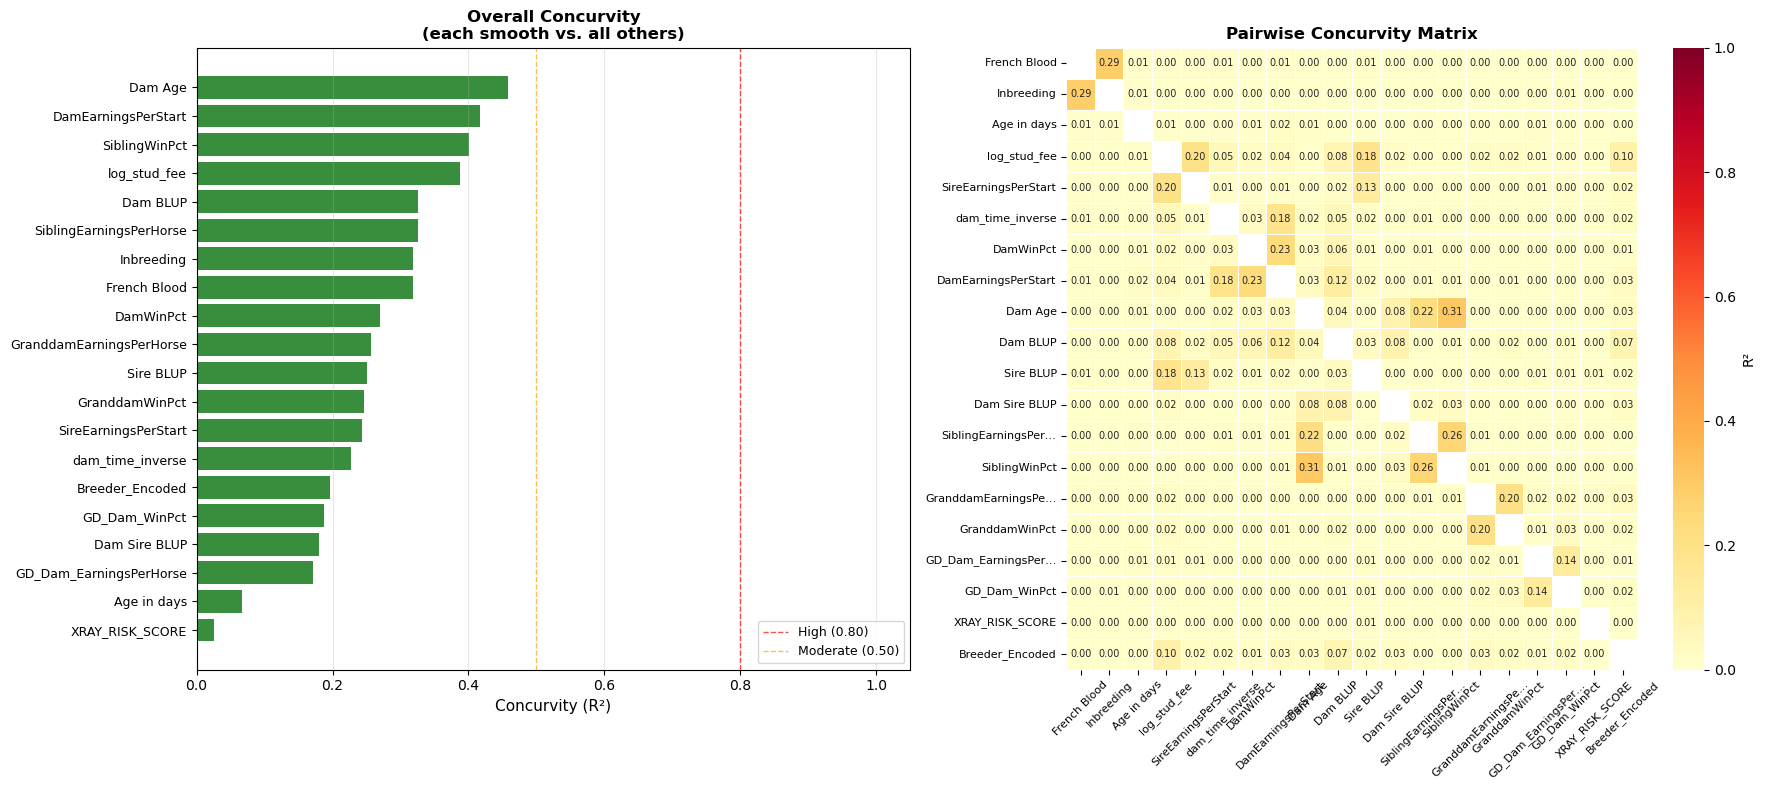


✓ Saved: gam_concurvity_analysis.svg
✓ Saved: gam_concurvity_overall.xlsx
✓ Saved: gam_concurvity_pairwise.xlsx

CONCURVITY RECOMMENDATIONS

  ✓ No severe or high concurvity detected.
    All smooth terms are reasonably independent.
    Individual smooth estimates and p-values are trustworthy.

  NOTE: Concurvity affects interpretation of individual terms
  (partial effects, p-values, EDF) but does NOT bias the overall
  model predictions. If your primary goal is prediction accuracy,
  concurvity is less of a concern than for inference.


In [50]:
# =========================================================
# CONCURVITY ANALYSIS FOR GAM
# =========================================================
# Concurvity is the GAM analog of multicollinearity.
# It measures whether one smooth term can be approximated
# by a combination of the other smooth terms.
#
# High concurvity → inflated variance, unreliable individual
# smooth estimates, unstable p-values.
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("=" * 70)
print("CONCURVITY ANALYSIS")
print("=" * 70)

# ---------------------------------------------------------
# 1. Extract per-term fitted values (partial predictions)
# ---------------------------------------------------------
# For each term, get the smooth's contribution to the
# linear predictor evaluated at the training data.

term_fitted = {}          # feature_name → vector of partial fits
term_names_smooth = []    # only smooth (spline) terms

for i, feat in enumerate(FEATURES):
    if feat in linear_features:
        continue  # skip binary/factor terms — concurvity is about smooths
    pdep = gam.partial_dependence(term=i, X=X_train_gam.values)
    term_fitted[feat] = pdep
    term_names_smooth.append(feat)

n_smooth = len(term_names_smooth)
print(f"\n[SMOOTH TERMS]: {n_smooth}")
for name in term_names_smooth:
    print(f"    - {name}")

# ---------------------------------------------------------
# 2. Overall (worst-case) concurvity
# ---------------------------------------------------------
# For each smooth term j, regress its fitted values on ALL
# other smooth terms' fitted values. R² = concurvity index.
#   0 → term is completely independent of others
#   1 → term is perfectly predicted by others (redundant)

print(f"\n{'=' * 70}")
print("OVERALL CONCURVITY (each term vs ALL others)")
print(f"{'=' * 70}")

overall_concurvity = {}

for j, target_name in enumerate(term_names_smooth):
    y_j = term_fitted[target_name]

    # Build matrix of all OTHER smooth terms
    other_names = [n for n in term_names_smooth if n != target_name]
    X_others = np.column_stack([term_fitted[n] for n in other_names])

    reg = LinearRegression().fit(X_others, y_j)
    r2 = reg.score(X_others, y_j)
    r2 = max(0.0, min(1.0, r2))  # clamp to [0, 1]

    overall_concurvity[target_name] = r2

# Display sorted by concurvity (highest first)
overall_df = (
    pd.DataFrame(
        [{"Feature": k, "Concurvity (R²)": v} for k, v in overall_concurvity.items()]
    )
    .sort_values("Concurvity (R²)", ascending=False)
    .reset_index(drop=True)
)

# Add severity label
def severity_label(r2):
    if r2 >= 0.90:
        return "⚠ SEVERE"
    elif r2 >= 0.80:
        return "⚠ HIGH"
    elif r2 >= 0.50:
        return "~ MODERATE"
    else:
        return "✓ LOW"

overall_df["Severity"] = overall_df["Concurvity (R²)"].apply(severity_label)

print(f"\n{'Feature':<30} {'Concurvity (R²)':>18} {'Severity':>14}")
print("-" * 65)
for _, row in overall_df.iterrows():
    print(f"{row['Feature']:<30} {row['Concurvity (R²)']:>18.4f} {row['Severity']:>14}")

print(f"\nInterpretation:")
print(f"  R² ≥ 0.90 : SEVERE  — term nearly redundant, estimates unreliable")
print(f"  R² ≥ 0.80 : HIGH    — substantial overlap, interpret with caution")
print(f"  R² ≥ 0.50 : MODERATE — some overlap, generally acceptable")
print(f"  R² < 0.50 : LOW     — term is reasonably independent")

n_severe = (overall_df["Concurvity (R²)"] >= 0.90).sum()
n_high = ((overall_df["Concurvity (R²)"] >= 0.80) & (overall_df["Concurvity (R²)"] < 0.90)).sum()
print(f"\n  Summary: {n_severe} severe, {n_high} high, "
      f"{n_smooth - n_severe - n_high} acceptable")

# ---------------------------------------------------------
# 3. Pairwise concurvity matrix
# ---------------------------------------------------------
# R² from regressing each term on every other term
# individually. Reveals WHICH pairs drive the overall
# concurvity.

print(f"\n{'=' * 70}")
print("PAIRWISE CONCURVITY MATRIX")
print(f"{'=' * 70}")

pairwise_matrix = np.zeros((n_smooth, n_smooth))

for j, target_name in enumerate(term_names_smooth):
    y_j = term_fitted[target_name].reshape(-1, 1)
    for k, pred_name in enumerate(term_names_smooth):
        if j == k:
            pairwise_matrix[j, k] = 1.0  # perfect self-prediction
            continue
        X_k = term_fitted[pred_name].reshape(-1, 1)
        reg = LinearRegression().fit(X_k, y_j)
        r2 = reg.score(X_k, y_j)
        pairwise_matrix[j, k] = max(0.0, min(1.0, r2))

pairwise_df = pd.DataFrame(
    pairwise_matrix,
    index=term_names_smooth,
    columns=term_names_smooth,
)

# ---------------------------------------------------------
# 4. Flag problematic pairs (R² > 0.60)
# ---------------------------------------------------------
print(f"\n[PROBLEMATIC PAIRWISE CONCURVITY (R² > 0.60)]")
print(f"{'Feature A':<30} {'Feature B':<30} {'R²':>8}")
print("-" * 70)

flagged_pairs = []
for j in range(n_smooth):
    for k in range(j + 1, n_smooth):
        r2 = pairwise_matrix[j, k]
        if r2 > 0.60:
            flagged_pairs.append(
                (term_names_smooth[j], term_names_smooth[k], r2)
            )

flagged_pairs.sort(key=lambda x: x[2], reverse=True)

if flagged_pairs:
    for a, b, r2 in flagged_pairs:
        print(f"{a:<30} {b:<30} {r2:>8.4f}")
else:
    print("  ✓ No pairwise concurvity exceeds 0.60 — smooth terms are reasonably independent")

# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot A: Overall concurvity bar chart ---
ax1 = axes[0]
sorted_df = overall_df.sort_values("Concurvity (R²)", ascending=True)
colors = []
for r2 in sorted_df["Concurvity (R²)"]:
    if r2 >= 0.90:
        colors.append("#d32f2f")   # red
    elif r2 >= 0.80:
        colors.append("#f57c00")   # orange
    elif r2 >= 0.50:
        colors.append("#fbc02d")   # yellow
    else:
        colors.append("#388e3c")   # green

ax1.barh(range(len(sorted_df)), sorted_df["Concurvity (R²)"], color=colors)
ax1.set_yticks(range(len(sorted_df)))
ax1.set_yticklabels(sorted_df["Feature"], fontsize=9)
ax1.set_xlabel("Concurvity (R²)", fontsize=11)
ax1.set_title("Overall Concurvity\n(each smooth vs. all others)", fontsize=12, fontweight="bold")
ax1.axvline(x=0.80, color="red", linestyle="--", linewidth=1, alpha=0.7, label="High (0.80)")
ax1.axvline(x=0.50, color="orange", linestyle="--", linewidth=1, alpha=0.7, label="Moderate (0.50)")
ax1.set_xlim(0, 1.05)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(axis="x", alpha=0.3)

# --- Plot B: Pairwise concurvity heatmap ---
ax2 = axes[1]

# Use short labels for readability
short_labels = []
for name in term_names_smooth:
    if len(name) > 20:
        short_labels.append(name[:18] + "…")
    else:
        short_labels.append(name)

# Mask the diagonal
mask = np.eye(n_smooth, dtype=bool)

sns.heatmap(
    pairwise_df.values,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    xticklabels=short_labels,
    yticklabels=short_labels,
    ax=ax2,
    cbar_kws={"label": "R²"},
    annot_kws={"size": 7},
    linewidths=0.5,
)
ax2.set_title("Pairwise Concurvity Matrix", fontsize=12, fontweight="bold")
ax2.tick_params(axis="x", rotation=45, labelsize=8)
ax2.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig("gam_concurvity_analysis.svg", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Saved: gam_concurvity_analysis.svg")

# ---------------------------------------------------------
# 6. Export results
# ---------------------------------------------------------
overall_df.to_excel("gam_concurvity_overall.xlsx", index=False)
pairwise_df.to_excel("gam_concurvity_pairwise.xlsx")
print("✓ Saved: gam_concurvity_overall.xlsx")
print("✓ Saved: gam_concurvity_pairwise.xlsx")

# ---------------------------------------------------------
# 7. Recommendations
# ---------------------------------------------------------
print(f"\n{'=' * 70}")
print("CONCURVITY RECOMMENDATIONS")
print(f"{'=' * 70}")

severe_features = overall_df[overall_df["Concurvity (R²)"] >= 0.90]["Feature"].tolist()
high_features = overall_df[
    (overall_df["Concurvity (R²)"] >= 0.80) & (overall_df["Concurvity (R²)"] < 0.90)
]["Feature"].tolist()

if severe_features:
    print(f"\n  SEVERE concurvity ({len(severe_features)} terms):")
    for feat in severe_features:
        # Find its strongest pairwise partner
        idx = term_names_smooth.index(feat)
        row = pairwise_matrix[idx].copy()
        row[idx] = 0  # exclude self
        partner_idx = np.argmax(row)
        partner = term_names_smooth[partner_idx]
        partner_r2 = row[partner_idx]
        print(f"    • {feat}")
        print(f"      Strongest pairwise overlap: {partner} (R²={partner_r2:.3f})")
    print(f"\n  → Consider removing or combining these features.")
    print(f"    Alternatively, accept the concurvity but note that")
    print(f"    individual smooth estimates and p-values for these terms")
    print(f"    may be unreliable (the overall model fit is not affected).")

if high_features:
    print(f"\n  HIGH concurvity ({len(high_features)} terms):")
    for feat in high_features:
        idx = term_names_smooth.index(feat)
        row = pairwise_matrix[idx].copy()
        row[idx] = 0
        partner_idx = np.argmax(row)
        partner = term_names_smooth[partner_idx]
        partner_r2 = row[partner_idx]
        print(f"    • {feat}  (strongest pair: {partner}, R²={partner_r2:.3f})")
    print(f"\n  → Monitor but generally acceptable for prediction.")

if not severe_features and not high_features:
    print(f"\n  ✓ No severe or high concurvity detected.")
    print(f"    All smooth terms are reasonably independent.")
    print(f"    Individual smooth estimates and p-values are trustworthy.")

print(f"\n  NOTE: Concurvity affects interpretation of individual terms")
print(f"  (partial effects, p-values, EDF) but does NOT bias the overall")
print(f"  model predictions. If your primary goal is prediction accuracy,")
print(f"  concurvity is less of a concern than for inference.")

In [14]:
# =========================================================
# GAM SUMMARY AND STATISTICS
# =========================================================

print("="*70)
print("GAM MODEL SUMMARY")
print("="*70)

# GAM summary statistics
print(gam.summary())

GAM MODEL SUMMARY
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     47.9892
Link Function:                     IdentityLink Log Likelihood:                                 -1331.1855
Number of Samples:                         1108 AIC:                                             2760.3494
                                                AICc:                                            2764.9787
                                                GCV:                                                0.4275
                                                Scale:                                              0.3943
                                                Pseudo R-Squared:                                   0.6288
Feature Function   

In [15]:
import numpy as np
import pandas as pd

edof_per_coef = np.asarray(gam.statistics_["edof_per_coef"])

rows = []
pos = 0  # running position in the coefficient vector

for term in gam.terms:
    n = term.n_coefs  # number of coefficients used by this term
    idx = slice(pos, pos + n)
    term_edf = float(edof_per_coef[idx].sum())
    pos += n

    if term.isintercept:
        rows.append({
            "term": "Intercept",
            "feature": "Intercept",
            "type": "Intercept",
            "EDF": round(term_edf, 2)
        })
        continue

    feat_name = FEATURES[term.feature]  # map column index -> name

    rows.append({
        "term": type(term).__name__,
        "feature": feat_name,
        "type": "Smooth" if "Spline" in type(term).__name__ else "Factor",
        "EDF": round(term_edf, 2)
    })

edf_named = (
    pd.DataFrame(rows)
      .sort_values("EDF", ascending=False)
      .reset_index(drop=True)
)

edf_named


,term,feature,type,EDF
0,SplineTerm,French Blood,Smooth,4.02
1,SplineTerm,log_stud_fee,Smooth,3.10
2,SplineTerm,SireEarningsPerStart,Smooth,2.64
3,SplineTerm,DamWinPct,Smooth,2.59
4,SplineTerm,Age in days,Smooth,2.54
5,SplineTerm,dam_time_inverse,Smooth,2.47
6,SplineTerm,Dam Age,Smooth,2.34
7,SplineTerm,Dam Sire BLUP,Smooth,2.33
8,SplineTerm,Sire BLUP,Smooth,2.12
9,SplineTerm,XRAY_RISK_SCORE,Smooth,2.07


In [16]:
# =========================================================
# FEATURE IMPORTANCE AND PARTIAL EFFECTS (with EDF + p)
# =========================================================

print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)


# ---- helpers ----
def format_p(p: float) -> str:
    """p-value formatting without scientific notation."""
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def sig_stars(p: float) -> str:
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def term_edf(gam, term_idx: int) -> float:
    """
    Compute EDF for a given term by summing edf contributions of the
    coefficients that belong to that term.
    """
    edof_per_coef = gam.statistics_.get("edof_per_coef", None)
    if edof_per_coef is None:
        return float("nan")
    coef_idx = gam.terms.get_coef_indices(term_idx)
    if coef_idx is None or len(coef_idx) == 0:
        return 0.0
    return float(edof_per_coef[coef_idx].sum())


# ---- Extract p-values ----
p_values = gam.statistics_["p_values"]

print("\n[STATISTICAL SIGNIFICANCE]")
print(f"{'Feature':<30} {'EDF':>6} {'P-value':>10} {'Significance':>14}")
print("-" * 70)

feature_stats = []
for i, feat in enumerate(FEATURES):
    p_val = float(p_values[i])
    edf = term_edf(gam, i)
    sig = sig_stars(p_val)

    feature_stats.append({
        "Feature": feat,
        "EDF": edf,
        "P-value": p_val,
        "P-value_fmt": format_p(p_val),
        "Significance": sig,
    })
    print(f"{feat:<30} {edf:>6.2f} {format_p(p_val):>10} {sig:>14}")

print("\n*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant")


# ---- Feature importance by partial dependence range ----
print("\n[FEATURE IMPORTANCE BY PARTIAL EFFECT RANGE]")
print("  (Larger range = stronger effect on predictions)")

importance_list = []
for i, feat in enumerate(FEATURES):
    XX = gam.generate_X_grid(term=i, n=100)
    pdep = gam.partial_dependence(term=i, X=XX)
    effect_range = float(pdep.max() - pdep.min())

    p_val = float(p_values[i])
    edf = term_edf(gam, i)

    importance_list.append({
        "Feature": feat,
        "Effect_Range": effect_range,
        "EDF": edf,
        "P-value": p_val,
        "P-value_fmt": format_p(p_val),
        "Significance": sig_stars(p_val),
    })

importance_df = pd.DataFrame(importance_list).sort_values("Effect_Range", ascending=False)

print(f"\n{'Rank':<6} {'Feature':<30} {'Effect Range':>12} {'EDF':>8} {'P-value':>10} {'Sig':>6}")
print("-" * 80)
for rank, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(
        f"{rank:<6} "
        f"{row['Feature']:<30} "
        f"{row['Effect_Range']:>12.4f} "
        f"{row['EDF']:>8.2f} "
        f"{row['P-value_fmt']:>10} "
        f"{row['Significance']:>6}"
    )

# Save Excel
importance_df.to_excel("gam_feature_importance.xlsx", index=False)
print("\n✓ Feature importance saved to gam_feature_importance.xlsx")


# EXPORT TO WORD (.docx)
# =========================================================
# pip install python-docx
from docx import Document as DocxDocument
from docx.shared import Pt, Inches, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import nsdecls
from docx.oxml import parse_xml

doc = DocxDocument()

# Title
doc.add_paragraph("Table X: GAM Feature Importance").bold = True

# Create table
headers = ["Rank", "Feature", "Effect Range", "EDF", "P-value", "Sig.", "Type"]
table = doc.add_table(rows=1, cols=len(headers))
table.style = "Light Grid Accent 1"

# Header row
for i, h in enumerate(headers):
    cell = table.rows[0].cells[i]
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data rows
for rank, (_, row) in enumerate(importance_df.iterrows(), 1):
    feat = row["Feature"]
    feat_type = "Factor" if feat in linear_features else "Smooth"
    values = [
        str(rank),
        feat,
        f"{row['Effect_Range']:.4f}",
        f"{row['EDF']:.2f}",
        row["P-value_fmt"],
        row["Significance"],
        feat_type,
    ]
    row_cells = table.add_row().cells
    for i, val in enumerate(values):
        row_cells[i].text = val
        if i != 1:  # center everything except Feature name
            row_cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Footnote
doc.add_paragraph(
    "*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant. "
    "Ranked by partial effect range. EDF = Effective Degrees of Freedom."
).italic = True

doc.save("gam_feature_importance_table.docx")
print("✓ Feature importance saved to gam_feature_importance_table.docx")

FEATURE IMPORTANCE ANALYSIS

[STATISTICAL SIGNIFICANCE]
Feature                           EDF    P-value   Significance
----------------------------------------------------------------------
French Blood                     4.02      0.059             ns
Inbreeding                       2.02      0.728             ns
Age in days                      2.54      0.748             ns
log_stud_fee                     3.10     <0.001            ***
SireEarningsPerStart             2.64      0.016              *
dam_time_inverse                 2.47      0.252             ns
DamWinPct                        2.59      0.308             ns
DamEarningsPerStart              1.71      0.021              *
Dam Age                          2.34      0.220             ns
Dam BLUP                         2.05     <0.001            ***
Sire BLUP                        2.12     <0.001            ***
Dam Sire BLUP                    2.33      0.061             ns
SiblingEarningsPerHorse          1.60    

In [17]:
# =========================================================
# FEATURE IMPORTANCE AND PARTIAL EFFECTS (with EDF + p)
# =========================================================

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# ---- helpers ----
def format_p(p: float) -> str:
    """ p-value formatting without scientific notation)."""
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def sig_stars(p: float) -> str:
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def term_edf(gam, term_idx: int) -> float:
    """
    Compute EDF for a given term by summing edf contributions of the
    coefficients that belong to that term.

    Works robustly even when pyGAM doesn't provide edf_per_term directly.
    """
    edof_per_coef = gam.statistics_.get("edof_per_coef", None)
    if edof_per_coef is None:
        return float("nan")

    # pyGAM exposes coefficient indices per term
    coef_idx = gam.terms.get_coef_indices(term_idx)

    # Some terms may have no coefficients (rare), guard anyway
    if coef_idx is None or len(coef_idx) == 0:
        return 0.0

    return float(edof_per_coef[coef_idx].sum())

# ---- Extract p-values ----
p_values = gam.statistics_["p_values"]

print("\n[STATISTICAL SIGNIFICANCE]")
print(f"{'Feature':<30} {'EDF':>6} {'P-value':>10} {'Significance':>14}")
print("-" * 70)

feature_stats = []

for i, feat in enumerate(FEATURES):
    p_val = float(p_values[i])
    edf = term_edf(gam, i)
    sig = sig_stars(p_val)

    feature_stats.append({
        "Feature": feat,
        "EDF": edf,
        "P-value": p_val,
        "P-value_fmt": format_p(p_val),
        "Significance": sig
    })

    print(f"{feat:<30} {edf:>6.2f} {format_p(p_val):>10} {sig:>14}")

print("\n*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant")

# ---- Feature importance by partial dependence range ----
print("\n[FEATURE IMPORTANCE BY PARTIAL EFFECT RANGE]")
print("  (Larger range = stronger effect on predictions)")

importance_list = []
for i, feat in enumerate(FEATURES):
    XX = gam.generate_X_grid(term=i, n=100)
    pdep = gam.partial_dependence(term=i, X=XX)
    effect_range = float(pdep.max() - pdep.min())

    p_val = float(p_values[i])
    edf = term_edf(gam, i)

    importance_list.append({
        "Feature": feat,
        "Effect_Range": effect_range,
        "EDF": edf,
        "P-value": p_val,
        "P-value_fmt": format_p(p_val),
        "Significance": sig_stars(p_val)
    })

importance_df = pd.DataFrame(importance_list).sort_values("Effect_Range", ascending=False)

print(f"\n{'Rank':<6} {'Feature':<30} {'Effect Range':>12} {'EDF':>8} {'P-value':>10} {'Sig':>6}")
print("-" * 80)
for rank, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(
        f"{rank:<6} "
        f"{row['Feature']:<30} "
        f"{row['Effect_Range']:>12.4f} "
        f"{row['EDF']:>8.2f} "
        f"{row['P-value_fmt']:>10} "
        f"{row['Significance']:>6}"
    )

# Save (keep numeric p-values + EDF + also the formatted p-value)
importance_df.to_excel("gam_feature_importance.xlsx", index=False)
print("\n✓ Feature importance saved to gam_feature_importance.csv")


FEATURE IMPORTANCE ANALYSIS

[STATISTICAL SIGNIFICANCE]
Feature                           EDF    P-value   Significance
----------------------------------------------------------------------
French Blood                     4.02      0.059             ns
Inbreeding                       2.02      0.728             ns
Age in days                      2.54      0.748             ns
log_stud_fee                     3.10     <0.001            ***
SireEarningsPerStart             2.64      0.016              *
dam_time_inverse                 2.47      0.252             ns
DamWinPct                        2.59      0.308             ns
DamEarningsPerStart              1.71      0.021              *
Dam Age                          2.34      0.220             ns
Dam BLUP                         2.05     <0.001            ***
Sire BLUP                        2.12     <0.001            ***
Dam Sire BLUP                    2.33      0.061             ns
SiblingEarningsPerHorse          1.60    

In [18]:
# =========================================================
# FEATURE IMPORTANCE AND PARTIAL EFFECTS
# =========================================================

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Extract p-values and statistics
print("\n[STATISTICAL SIGNIFICANCE]")
print(f"{'Feature':<30} {'P-value':<12} {'Significance'}")
print("-" * 60)

p_values = gam.statistics_['p_values']
feature_stats = []

for i, feat in enumerate(FEATURES):
    p_val = p_values[i]
    if p_val < 0.001:
        sig = "***"
    elif p_val < 0.01:
        sig = "**"
    elif p_val < 0.05:
        sig = "*"
    else:
        sig = "ns"
    
    feature_stats.append({
        'Feature': feat,
        'P-value': p_val,
        'Significance': sig
    })
    
    print(f"{feat:<30} {p_val:<12.4e} {sig}")

print("\n*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant")

# Feature importance by partial dependence range
print("\n[FEATURE IMPORTANCE BY PARTIAL EFFECT RANGE]")
print("  (Larger range = stronger effect on predictions)")

importance_list = []
for i, feat in enumerate(FEATURES):
    # Generate partial dependence
    XX = gam.generate_X_grid(term=i, n=100)
    pdep = gam.partial_dependence(term=i, X=XX)
    
    # Measure range
    effect_range = pdep.max() - pdep.min()
    
    importance_list.append({
        'Feature': feat,
        'Effect_Range': effect_range,
        'P-value': p_values[i]
    })

importance_df = pd.DataFrame(importance_list).sort_values('Effect_Range', ascending=False)

print(f"\n{'Rank':<6} {'Feature':<30} {'Effect Range':<15} {'P-value'}")
print("-" * 70)
for rank, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(f"{rank:<6} {row['Feature']:<30} {row['Effect_Range']:<15.4f} {row['P-value']:.4e}")

importance_df.to_csv('gam_feature_importance.csv', index=False)
print("\n✓ Feature importance saved to gam_feature_importance.csv")

FEATURE IMPORTANCE ANALYSIS

[STATISTICAL SIGNIFICANCE]
Feature                        P-value      Significance
------------------------------------------------------------
French Blood                   5.8988e-02   ns
Inbreeding                     7.2799e-01   ns
Age in days                    7.4819e-01   ns
log_stud_fee                   1.1102e-16   ***
SireEarningsPerStart           1.5982e-02   *
dam_time_inverse               2.5206e-01   ns
DamWinPct                      3.0762e-01   ns
DamEarningsPerStart            2.1361e-02   *
Dam Age                        2.2022e-01   ns
Dam BLUP                       4.7156e-04   ***
Sire BLUP                      5.4796e-05   ***
Dam Sire BLUP                  6.0966e-02   ns
SiblingEarningsPerHorse        2.3301e-09   ***
SiblingWinPct                  7.9895e-01   ns
GranddamEarningsPerHorse       1.4139e-01   ns
GranddamWinPct                 7.3574e-03   **
GD_Dam_EarningsPerHorse        4.7611e-02   *
GD_Dam_WinPct             

PARTIAL DEPENDENCE PLOTS - ALL FEATURES


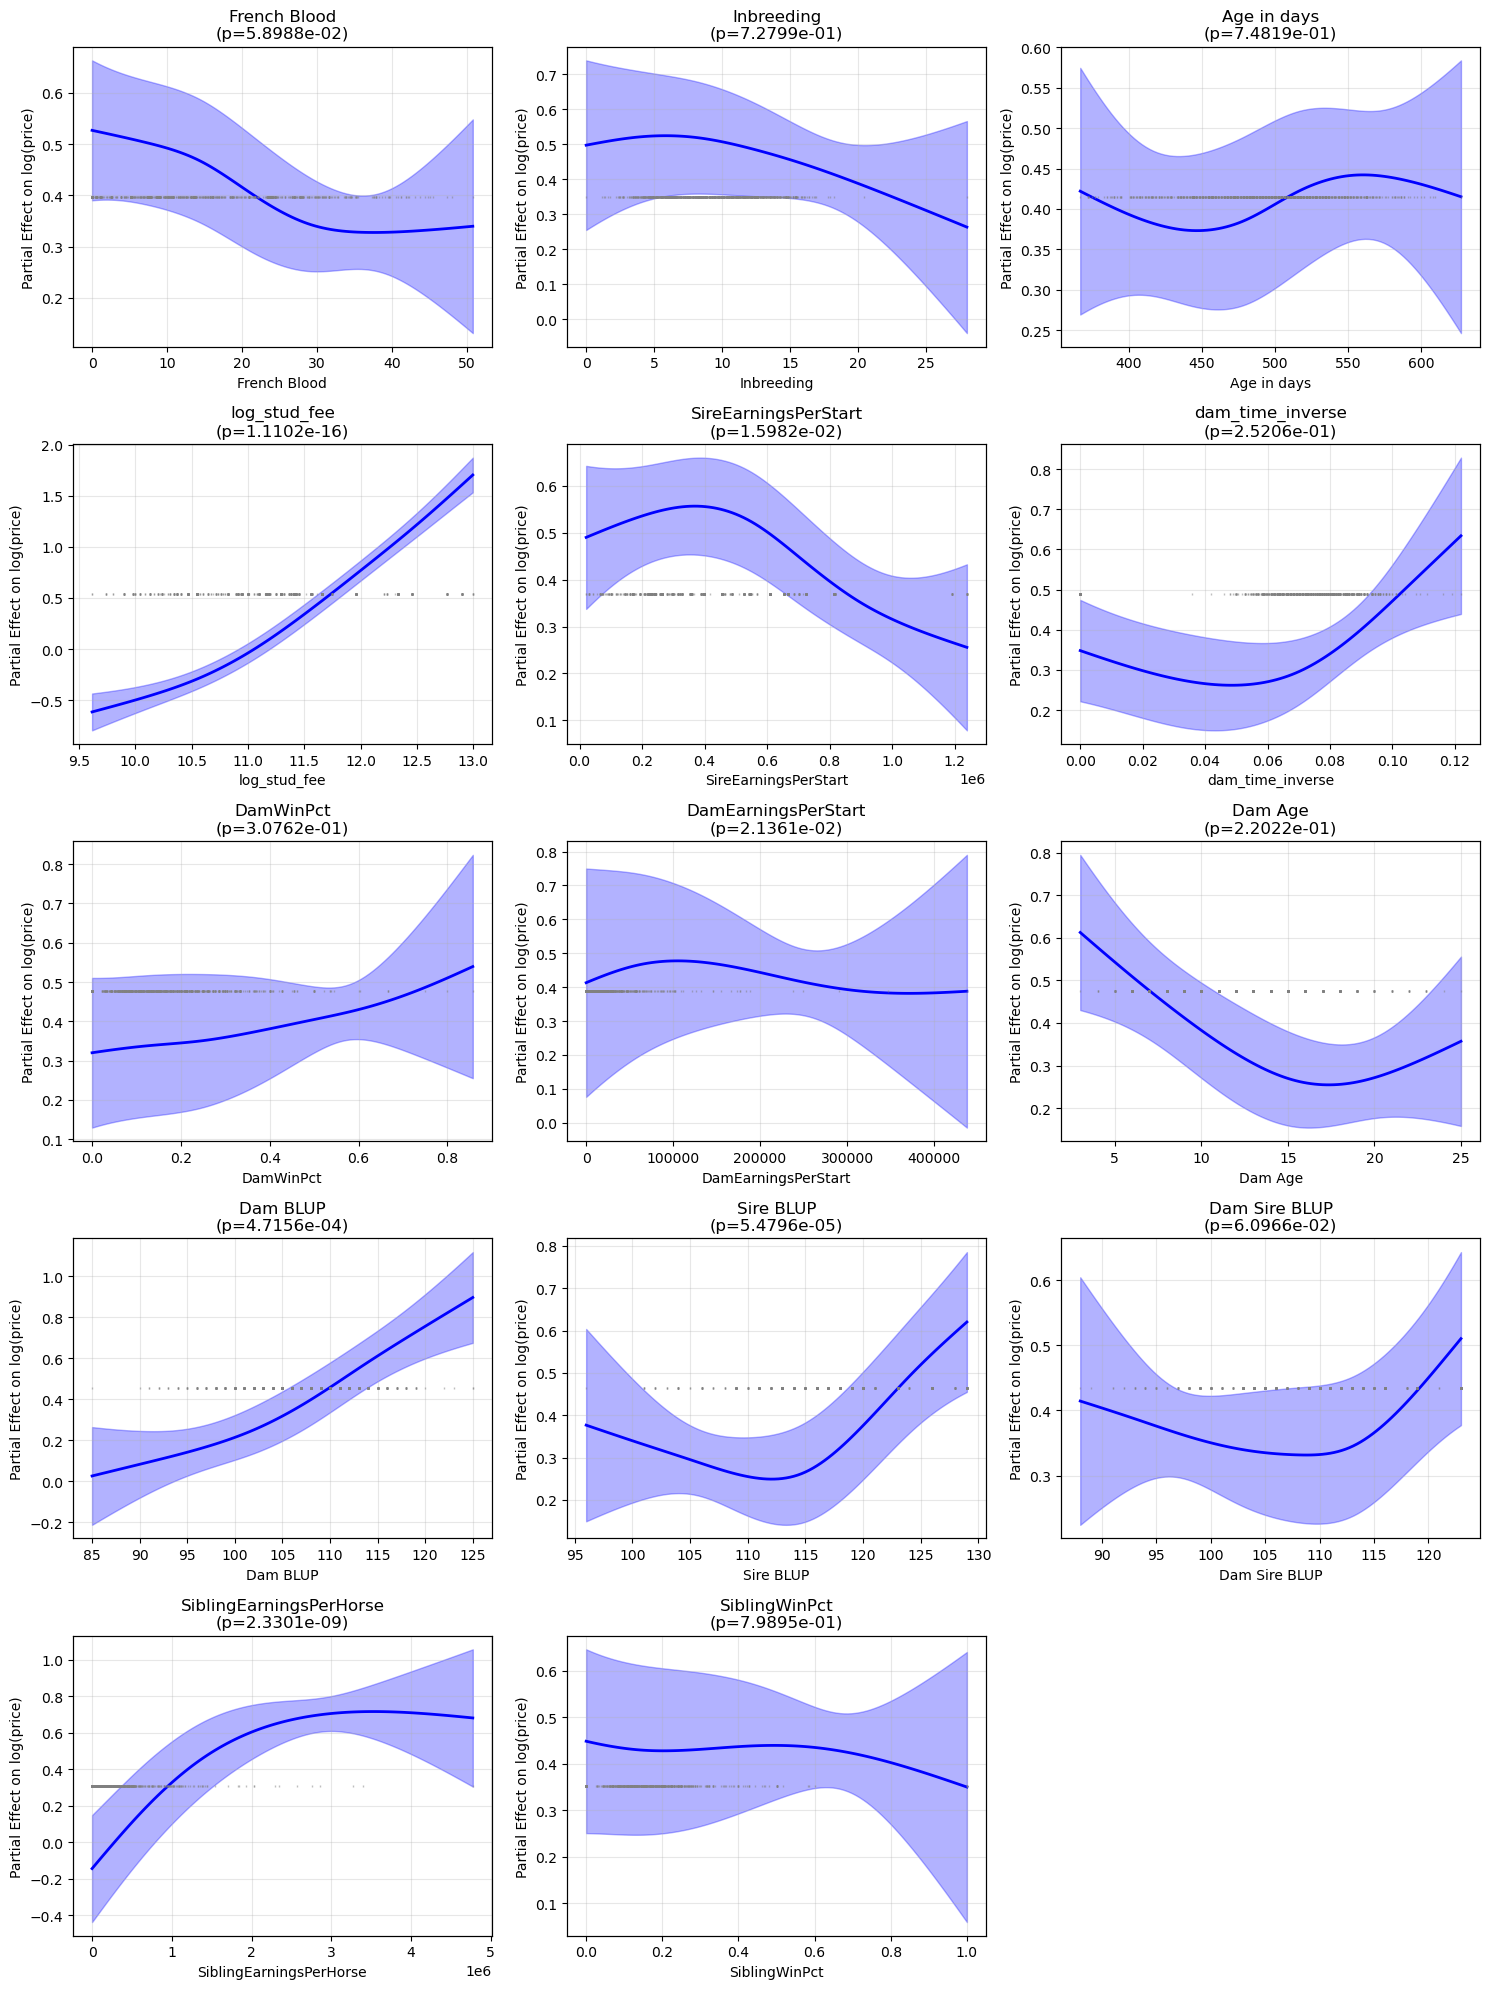

✓ Saved: gam_partial_dependence_part1.svg


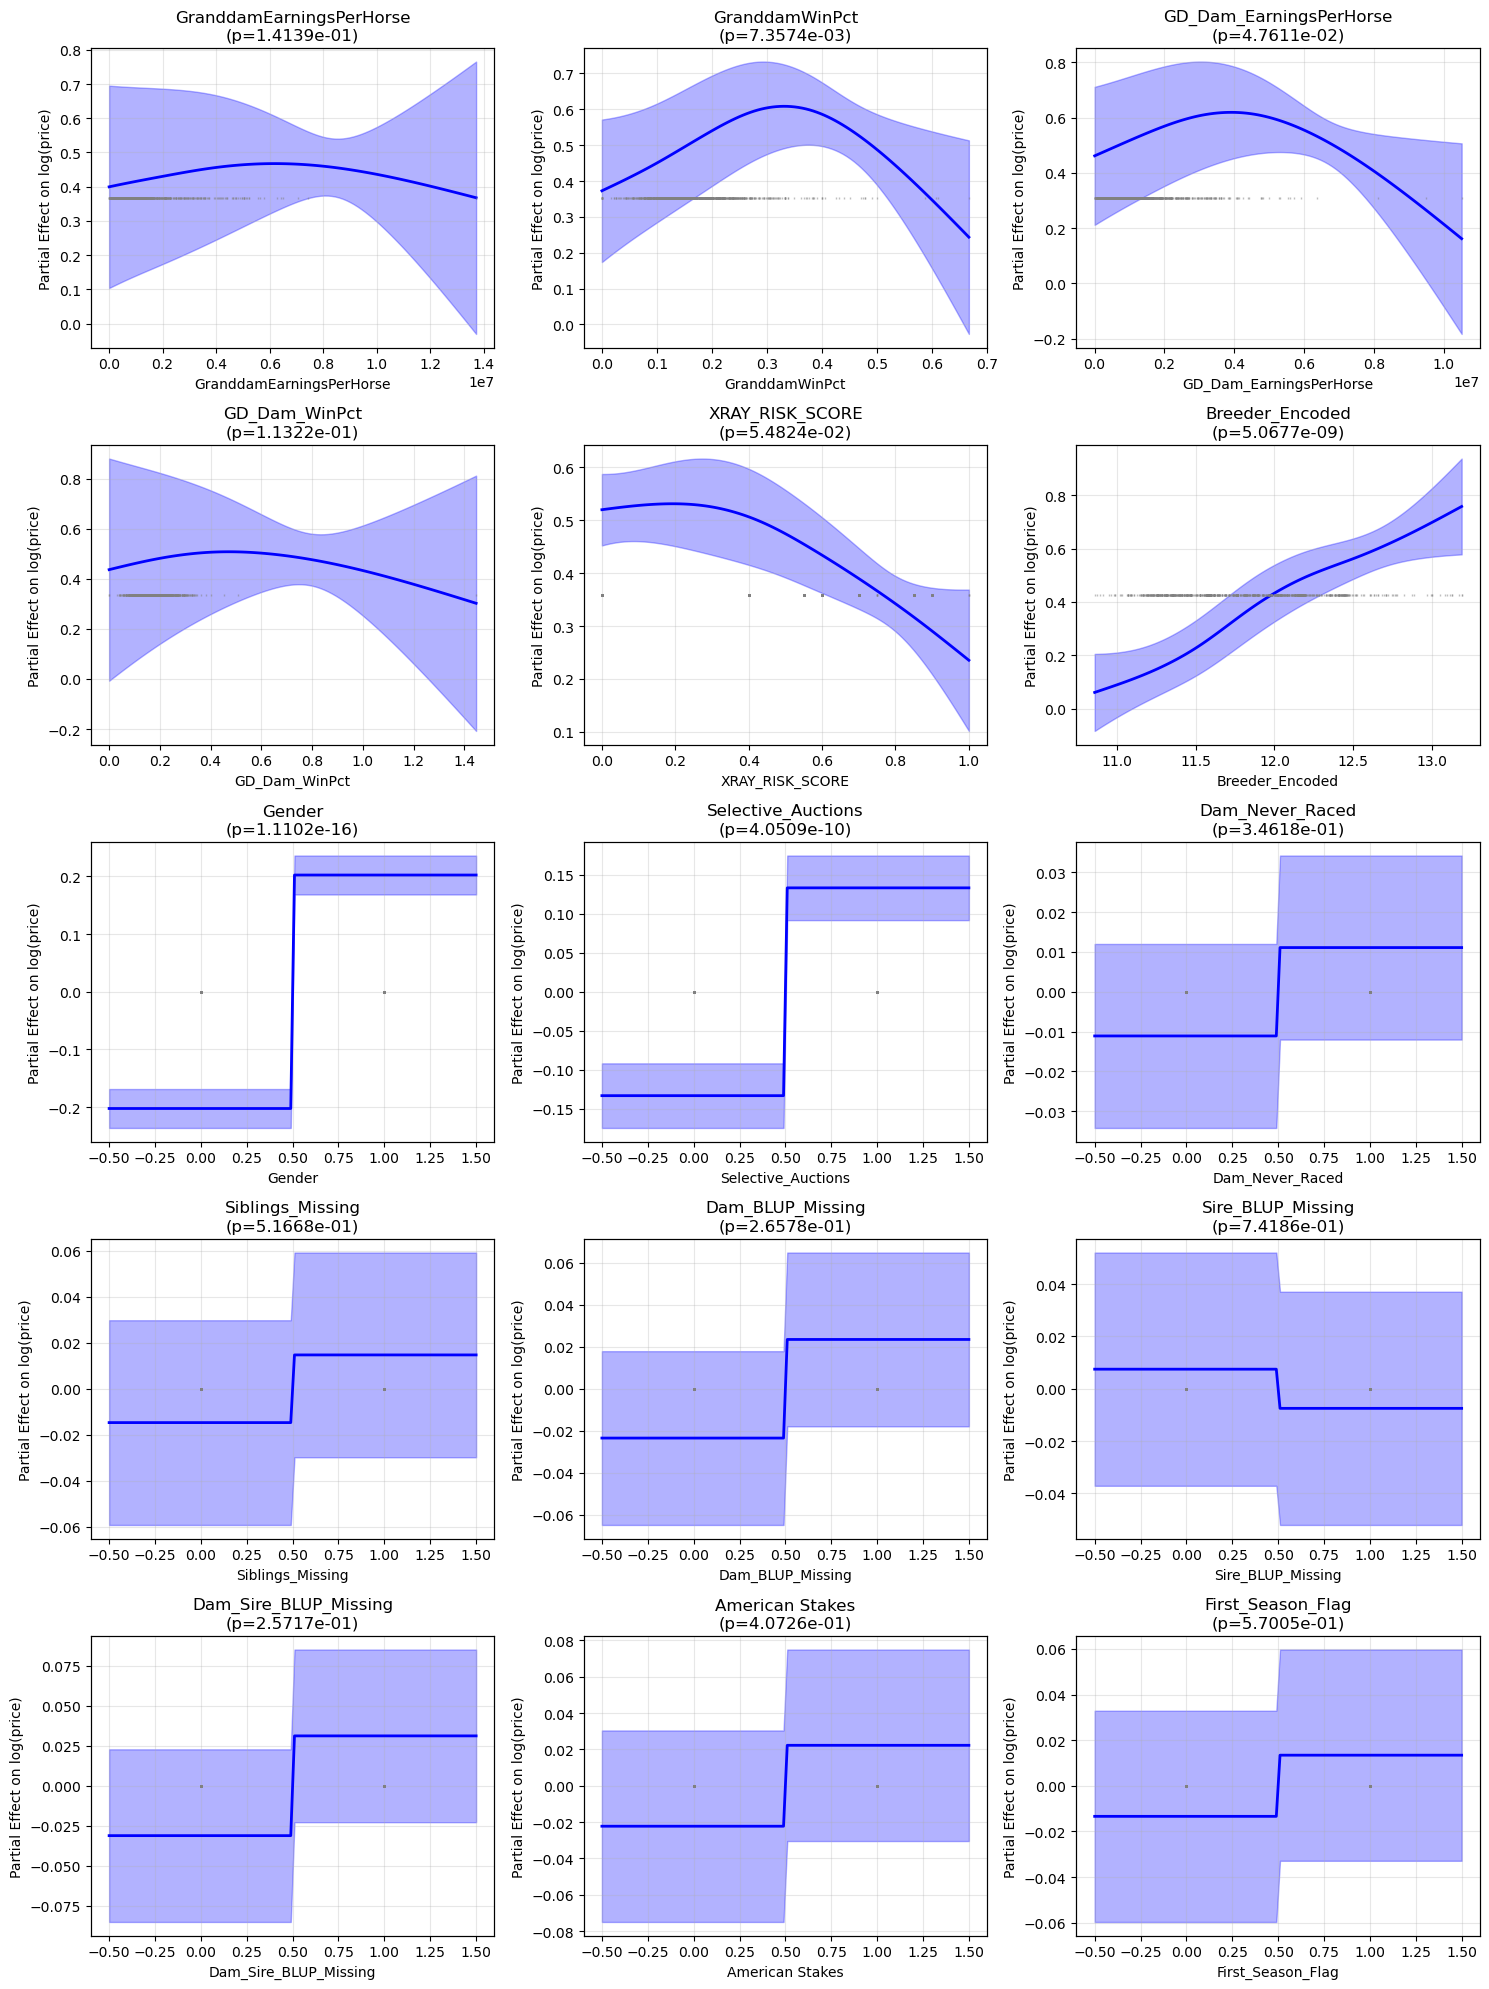

✓ Saved: gam_partial_dependence_part2.svg


In [20]:
# =========================================================
# PARTIAL DEPENDENCE PLOTS - ALL FEATURES (TWO FIGURES)
# =========================================================
print("=" * 70)
print("PARTIAL DEPENDENCE PLOTS - ALL FEATURES")
print("=" * 70)

n_features = len(FEATURES)
mid = n_features // 2  # Split point

for fig_num, (start, end) in enumerate([(0, mid), (mid, n_features)], 1):
    subset = FEATURES[start:end]
    n_cols = 3
    n_rows = int(np.ceil(len(subset) / n_cols))

    fig = plt.figure(figsize=(15, 4 * n_rows))

    for j, feat in enumerate(subset):
        i = start + j  # Original feature index
        ax = plt.subplot(n_rows, n_cols, j + 1)
        XX = gam.generate_X_grid(term=i, n=100)

        pdep, conf_intervals = gam.partial_dependence(term=i, X=XX, width=0.95)

        ax.plot(XX[:, i], pdep, 'b-', linewidth=2)
        ax.fill_between(XX[:, i],
                         conf_intervals[:, 0],
                         conf_intervals[:, 1],
                         alpha=0.3, color='blue')

        ax.set_xlabel(feat)
        ax.set_ylabel('Partial Effect on log(price)')
        ax.set_title(f'{feat}\n(p={p_values[i]:.4e})')
        ax.grid(True, alpha=0.3)

        # Rug plot
        ax_rug = ax.twinx()
        ax_rug.set_yticks([])
        sample_data = X_train.iloc[:, i].values
        ax_rug.plot(sample_data, np.zeros_like(sample_data), '|',
                    color='gray', alpha=0.5, markersize=2)

    plt.tight_layout()
    plt.savefig(f'gam_partial_dependence_part{fig_num}.svg', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: gam_partial_dependence_part{fig_num}.svg")

DETAILED PARTIAL DEPENDENCE - TOP 6 FEATURES


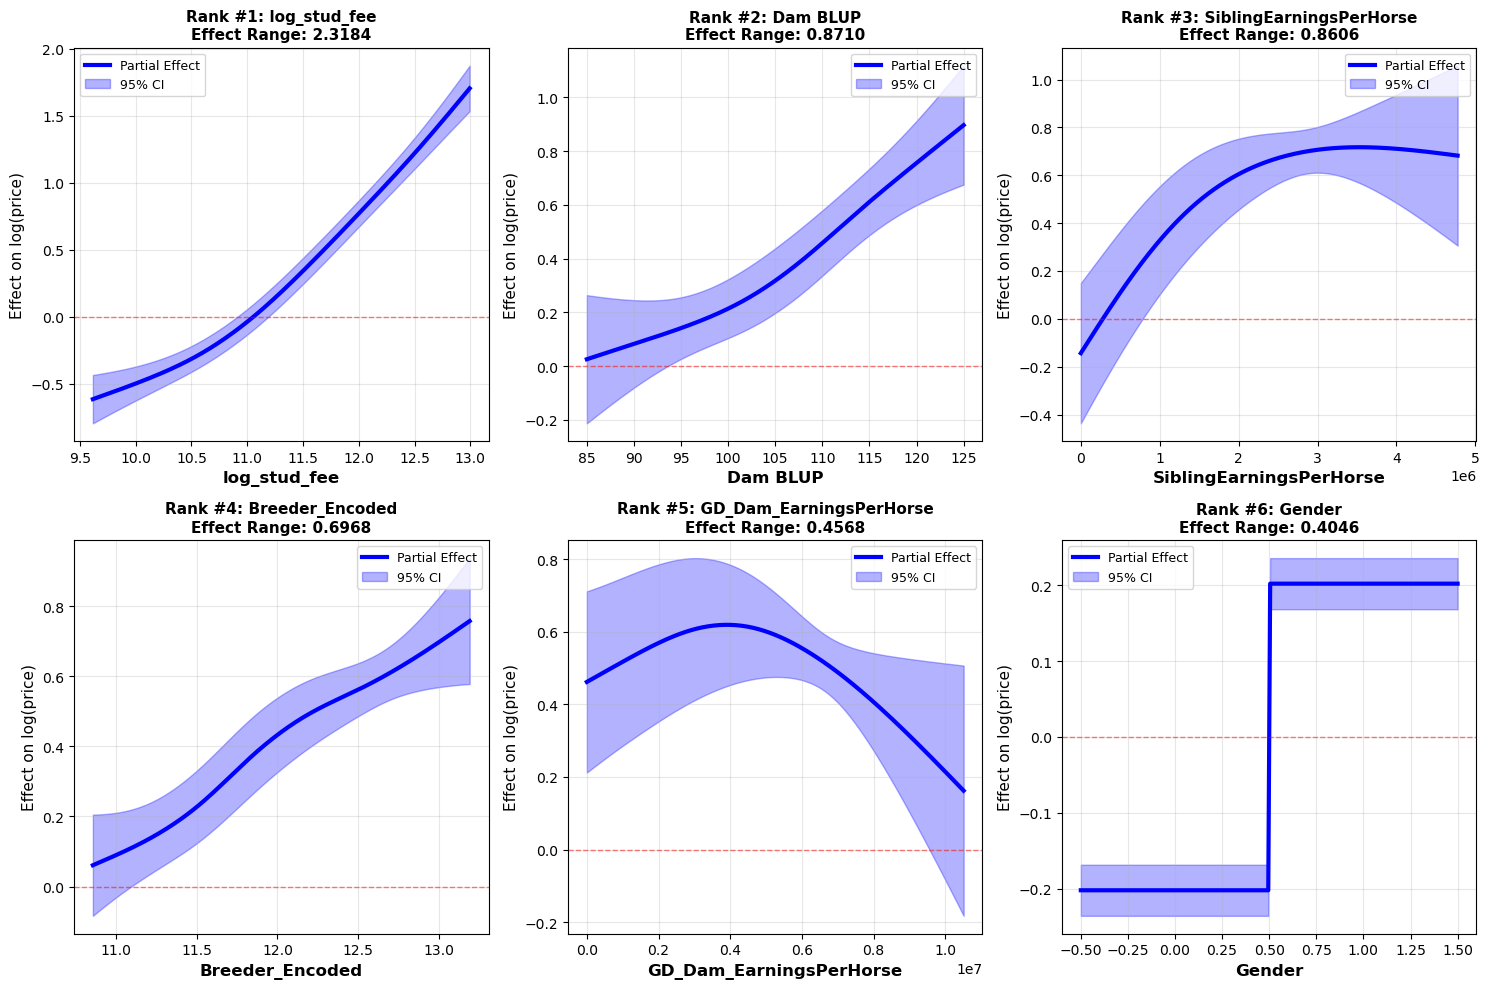

✓ Saved: gam_top_features.svg


In [21]:
# =========================================================
# TOP FEATURES DETAILED PLOTS
# =========================================================

print("="*70)
print("DETAILED PARTIAL DEPENDENCE - TOP 6 FEATURES")
print("="*70)

# Get top 6 most important features
top_features = importance_df.head(6)['Feature'].tolist()
top_indices = [FEATURES.index(feat) for feat in top_features]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (i, feat) in enumerate(zip(top_indices, top_features)):
    ax = axes[idx]
    
    XX = gam.generate_X_grid(term=i, n=200)
    
    # Get partial dependence and confidence intervals
    pdep, conf_intervals = gam.partial_dependence(term=i, X=XX, width=0.95)
    
    # Plot
    ax.plot(XX[:, i], pdep, 'b-', linewidth=3, label='Partial Effect')
    ax.fill_between(XX[:, i], 
                     conf_intervals[:, 0],  # Lower bound
                     conf_intervals[:, 1],  # Upper bound
                     alpha=0.3, color='blue', label='95% CI')
    
    ax.set_xlabel(feat, fontsize=12, fontweight='bold')
    ax.set_ylabel('Effect on log(price)', fontsize=11)
    ax.set_title(f'Rank #{idx+1}: {feat}\nEffect Range: {importance_df.iloc[idx]["Effect_Range"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    
    # Reference line
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('gam_top_features.svg', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: gam_top_features.svg")

RESIDUAL ANALYSIS

[LOG SCALE RESIDUALS]
  Mean:     -0.0429
  Median:   -0.0463
  Std:      0.7540
  Skewness: -0.0502
  Kurtosis: -0.4034

[PRICE SCALE RESIDUALS]
  Mean:     -6,544 NOK
  Median:   +22,722 NOK

[NORMALITY TESTS - LOG SCALE]
  Shapiro-Wilk: W=0.9944, p=0.0610 → Normal ✓
  Jarque-Bera: JB=3.6722, p=0.1594 → Normal ✓

[INTERPRETATION]
  Skewness (-0.05): Approximately symmetric ✓
  Kurtosis (-0.40): Near normal tails ✓


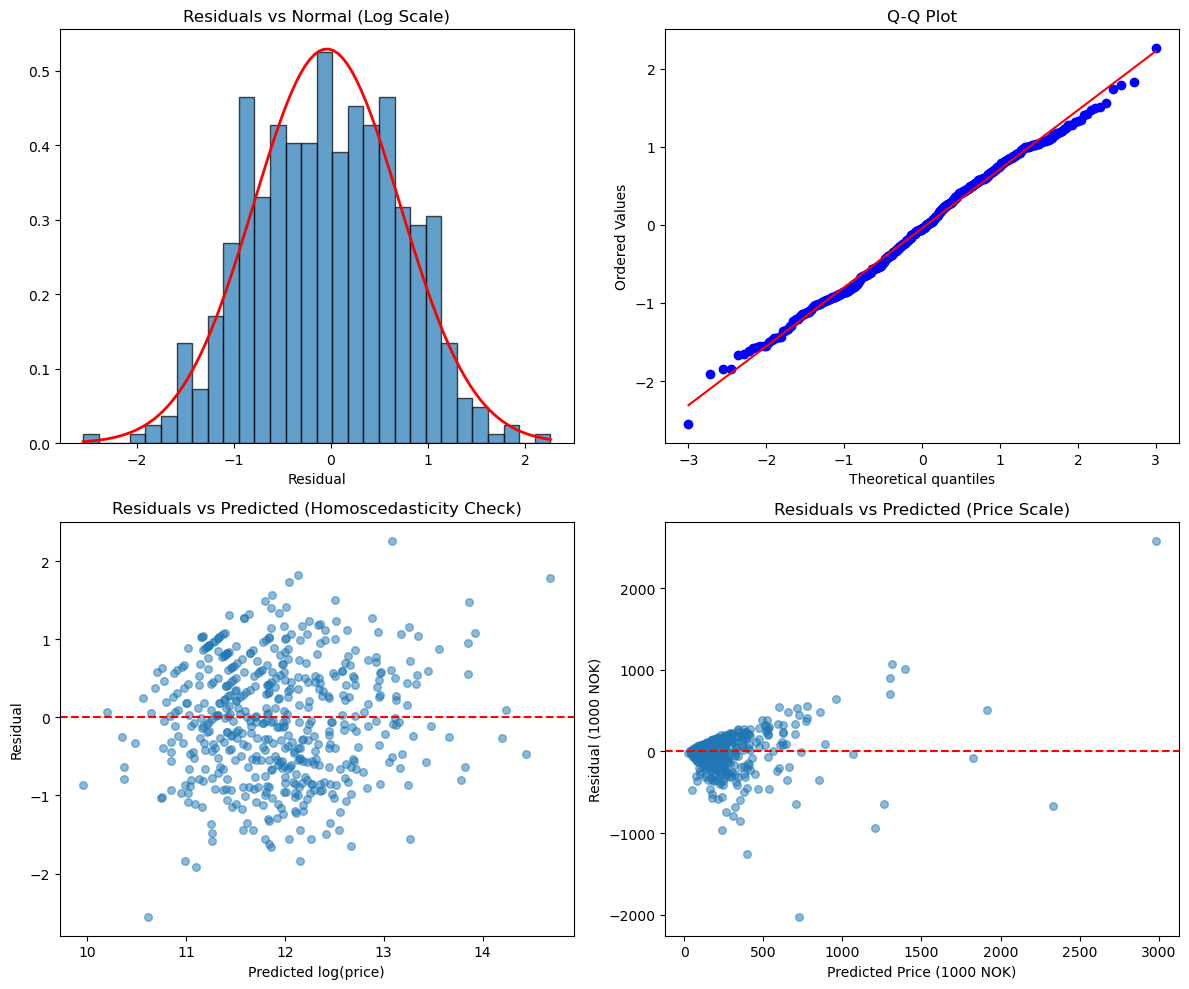


✓ Saved: gam_residual_analysis.svg


In [52]:
# =========================================================
# RESIDUAL ANALYSIS
# =========================================================
from scipy import stats

print("="*70)
print("RESIDUAL ANALYSIS")
print("="*70)

residuals_log =  pred_test - y_test.values 
#residuals_price = y_test_price - pred_test_price  # Already numpy arrays
residuals_price = pred_test_price - y_test_price

# Descriptive statistics
print(f"\n[LOG SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_log):.4f}")
print(f"  Median:   {np.median(residuals_log):.4f}")
print(f"  Std:      {np.std(residuals_log):.4f}")
print(f"  Skewness: {stats.skew(residuals_log):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_log):.4f}")

print(f"\n[PRICE SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_price):+,.0f} NOK")
print(f"  Median:   {np.median(residuals_price):+,.0f} NOK")

# Normality tests
print(f"\n[NORMALITY TESTS - LOG SCALE]")
if len(residuals_log) <= 5000:
    stat_sw, p_sw = stats.shapiro(residuals_log)
    result_sw = "Normal ✓" if p_sw > 0.05 else "Not Normal ✗"
    print(f"  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} → {result_sw}")

stat_jb, p_jb = stats.jarque_bera(residuals_log)
result_jb = "Normal ✓" if p_jb > 0.05 else "Not Normal ✗"
print(f"  Jarque-Bera: JB={stat_jb:.4f}, p={p_jb:.4f} → {result_jb}")

# Interpretation
skewness = stats.skew(residuals_log)
kurtosis = stats.kurtosis(residuals_log)

print(f"\n[INTERPRETATION]")
if abs(skewness) < 0.5:
    print(f"  Skewness ({skewness:.2f}): Approximately symmetric ✓")
else:
    print(f"  Skewness ({skewness:.2f}): {'Right' if skewness > 0 else 'Left'}-skewed")

if abs(kurtosis) < 1:
    print(f"  Kurtosis ({kurtosis:.2f}): Near normal tails ✓")
else:
    print(f"  Kurtosis ({kurtosis:.2f}): {'Heavy' if kurtosis > 0 else 'Light'} tails")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogram
ax1 = axes[0, 0]
ax1.hist(residuals_log, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(residuals_log.min(), residuals_log.max(), 100)
ax1.plot(x, stats.norm.pdf(x, np.mean(residuals_log), np.std(residuals_log)), 'r-', lw=2)
ax1.set_title('Residuals vs Normal (Log Scale)')
ax1.set_xlabel('Residual')

# Q-Q plot
ax2 = axes[0, 1]
stats.probplot(residuals_log, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')

# Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(pred_test, residuals_log, alpha=0.5, s=30)
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted log(price)')
ax3.set_ylabel('Residual')
ax3.set_title('Residuals vs Predicted (Homoscedasticity Check)')

# Residuals vs Fitted (price scale)
ax4 = axes[1, 1]
ax4.scatter(pred_test_price/1000, residuals_price/1000, alpha=0.5, s=30)
ax4.axhline(y=0, color='r', linestyle='--')
ax4.set_xlabel('Predicted Price (1000 NOK)')
ax4.set_ylabel('Residual (1000 NOK)')
ax4.set_title('Residuals vs Predicted (Price Scale)')

plt.tight_layout()
plt.savefig('gam_residual_analysis.svg', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: gam_residual_analysis.svg")

In [54]:
# =========================================================
# SAVE MODEL AND SUMMARY
# =========================================================

import pickle

print("="*70)
print("SAVE MODEL")
print("="*70)

# Save model
with open("gam_horse_prices.pkl", 'wb') as file:
    pickle.dump(gam, file)
print("\n✓ Model saved to gam_horse_prices.pkl")

# Save config
config = {
    'features': FEATURES,
    'smooth_features': smooth_features,
    'linear_features': linear_features,
    'sigma2': sigma2,
    'metrics': gam_results,
    'feature_importance': importance_df.to_dict('records'),
    'lambda': gam.lam.tolist() if hasattr(gam.lam, 'tolist') else gam.lam,
}

with open("gam_config.pkl", "wb") as file:
    pickle.dump(config, file)
print("✓ Config saved to gam_config.pkl")

# Final summary
print(f"\n{'='*70}")
print("FINAL SUMMARY: GAM MODEL")
print(f"{'='*70}")

print(f"\n[MODEL]")
print(f"  Type: Generalized Additive Model (GAM)")
print(f"  Features: {len(FEATURES)}")
print(f"    - Smooth (spline): {len(smooth_features)}")
print(f"    - Linear/factor:   {len(linear_features)}")

print(f"\n[PERFORMANCE]")
print(f"  Train R²: {gam_results['train_r2_log']:.4f}")
print(f"  Test R²:  {gam_results['test_r2_log']:.4f}")
print(f"  Gap:      {gam_results['train_r2_log'] - gam_results['test_r2_log']:.4f}")

print(f"\n[PRICE SCALE]")
print(f"  RMSE:  {gam_results['rmse_price']:,.0f} NOK")
print(f"  MAE:   {gam_results['mae_price']:,.0f} NOK")
print(f"  MAPE:  {gam_results['mape_price']:.1f}%")
print(f"  MdAPE: {gam_results['mdape_price']:.1f}%")

print(f"\n[TOP 5 MOST IMPORTANT FEATURES]")
print(f"  (by partial effect range)")
for _, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Effect_Range']:.4f} (p={row['P-value']:.4e})")

SAVE MODEL

✓ Model saved to gam_horse_prices.pkl
✓ Config saved to gam_config.pkl

FINAL SUMMARY: GAM MODEL

[MODEL]
  Type: Generalized Additive Model (GAM)
  Features: 29
    - Smooth (spline): 20
    - Linear/factor:   9

[PERFORMANCE]
  Train R²: 0.6288
  Test R²:  0.4261
  Gap:      0.2028

[PRICE SCALE]
  RMSE:  265,235 NOK
  MAE:   151,779 NOK
  MAPE:  86.0%
  MdAPE: 53.4%

[TOP 5 MOST IMPORTANT FEATURES]
  (by partial effect range)
  log_stud_fee: 2.3184 (p=1.1102e-16)
  Dam BLUP: 0.8710 (p=4.7156e-04)
  SiblingEarningsPerHorse: 0.8606 (p=2.3301e-09)
  Breeder_Encoded: 0.6968 (p=5.0677e-09)
  GD_Dam_EarningsPerHorse: 0.4568 (p=4.7611e-02)


In [24]:
# =========================================================
# PREDICTIONS FOR EACH HORSE IN TEST SET
# =========================================================

print("="*70)
print("INDIVIDUAL HORSE PREDICTIONS")
print("="*70)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Actual_Price_NOK': np.exp(y_test),
    'Predicted_Price_NOK': pred_test_price,
    'Error_NOK': pred_test_price - np.exp(y_test),
    'Error_Pct': ((pred_test_price - np.exp(y_test)) / np.exp(y_test)) * 100,
    'Abs_Error_NOK': np.abs(pred_test_price - np.exp(y_test)),
    'Abs_Error_Pct': np.abs((pred_test_price - np.exp(y_test)) / np.exp(y_test)) * 100,
    'Log_Actual': y_test,
    'Log_Predicted': pred_test
}, index=y_test.index)

# Add horse identifiers if available in original dataframe
# Try to add horse name, year, auction, and other identifiers
identifier_cols = ['Horse', 'Name', col_year, col_auction, col_gender, col_age]
for col in identifier_cols:
    if col and col in df.columns:
        predictions_df[col] = df.loc[y_test.index, col]

# Sort by absolute error (worst predictions first)
predictions_df_sorted = predictions_df.sort_values('Abs_Error_NOK', ascending=False)

print(f"\nTotal predictions: {len(predictions_df)}")
print(f"\n[SUMMARY STATISTICS]")
print(f"  Mean Absolute Error:    {predictions_df['Abs_Error_NOK'].mean():,.0f} NOK")
print(f"  Median Absolute Error:  {predictions_df['Abs_Error_NOK'].median():,.0f} NOK")
print(f"  Mean Error %:           {predictions_df['Error_Pct'].mean():.1f}%")
print(f"  Median Abs Error %:     {predictions_df['Abs_Error_Pct'].median():.1f}%")

print(f"\n[TOP 10 WORST PREDICTIONS - OVERPRICED]")
print("(Model predicted higher than actual price)")
overpriced = predictions_df_sorted[predictions_df_sorted['Error_NOK'] > 0].head(10)
for idx, row in overpriced.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

print(f"\n[TOP 10 WORST PREDICTIONS - UNDERPRICED]")
print("(Model predicted lower than actual price)")
underpriced = predictions_df_sorted[predictions_df_sorted['Error_NOK'] < 0].head(10)
for idx, row in underpriced.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

print(f"\n[BEST 10 PREDICTIONS]")
best = predictions_df.sort_values('Abs_Error_NOK').head(10)
for idx, row in best.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

# Save to CSV
predictions_df_sorted.to_csv('gam_predictions.csv', index=True)
print(f"\n✓ Predictions saved to gam_predictions.csv")

# Display first few rows
print(f"\n[FIRST 20 PREDICTIONS]")
display_cols = ['Actual_Price_NOK', 'Predicted_Price_NOK', 'Error_NOK', 'Error_Pct']
if col_year in predictions_df.columns:
    display_cols.insert(0, col_year)
print(predictions_df_sorted[display_cols].head(20).to_string())

INDIVIDUAL HORSE PREDICTIONS

Total predictions: 510

[SUMMARY STATISTICS]
  Mean Absolute Error:    153,377 NOK
  Median Absolute Error:  83,609 NOK
  Mean Error %:           57.8%
  Median Abs Error %:     53.2%

[TOP 10 WORST PREDICTIONS - OVERPRICED]
(Model predicted higher than actual price)
  Index 1590: Actual=400,000 NOK, Predicted=2,981,680 NOK, Error=+645.4%
  Index 1524: Actual=240,000 NOK, Predicted=1,312,038 NOK, Error=+446.7%
  Index 1453: Actual=380,000 NOK, Predicted=1,394,055 NOK, Error=+266.9%
  Index 1503: Actual=400,000 NOK, Predicted=1,301,761 NOK, Error=+225.4%
  Index 1153: Actual=600,000 NOK, Predicted=1,302,275 NOK, Error=+117.0%
  Index 1596: Actual=320,000 NOK, Predicted=961,695 NOK, Error=+200.5%
  Index 1575: Actual=220,000 NOK, Predicted=778,015 NOK, Error=+253.6%
  Index 1545: Actual=50,000 NOK, Predicted=599,902 NOK, Error=+1099.8%
  Index 1563: Actual=180,000 NOK, Predicted=711,855 NOK, Error=+295.5%
  Index 1614: Actual=1,400,000 NOK, Predicted=1,912,3

In [25]:
predictions_df.to_excel("GAM_2025_PREDICTIONS.xlsx", index=True)

In [26]:
# =========================================================
# ANALYZE PRICE BUILD-UP FOR A SINGLE HORSE
# =========================================================

def analyze_horse_gam_prediction(horse_index, show_top_n=10):
    """
    Break down the GAM price prediction for a single horse.
    Shows how each feature contributes through partial effects.
    """
    
    if horse_index not in y_test.index:
        print(f"Error: Index {horse_index} not found in test set")
        return
    
    print("="*70)
    print(f"GAM PRICE BUILD-UP ANALYSIS FOR HORSE INDEX {horse_index}")
    print("="*70)
    
    # Get the horse's features
    horse_features = X_test.loc[horse_index].values
    
    # Get identifiers
    print("\n[HORSE INFORMATION]")
    identifier_cols = ['Horse', 'Name', col_year, col_auction, col_gender, col_age]
    for col in identifier_cols:
        if col and col in df.columns:
            print(f"  {col}: {df.loc[horse_index, col]}")
    
    # Actual vs Predicted
    actual_price = np.exp(y_test.loc[horse_index])
    test_loc = y_test.index.get_loc(horse_index)
    predicted_log = pred_test[test_loc]
    predicted_price = pred_test_price[test_loc]
    error_pct = ((predicted_price - actual_price) / actual_price) * 100
    
    print(f"\n[PRICES]")
    print(f"  Actual Price:    {actual_price:>12,.0f} NOK")
    print(f"  Predicted Price: {predicted_price:>12,.0f} NOK")
    print(f"  Error:           {predicted_price - actual_price:>12,.0f} NOK ({error_pct:+.1f}%)")
    
    # Calculate feature contributions via partial effects
    print(f"\n[PREDICTION BUILD-UP VIA PARTIAL EFFECTS]")
    
    # Get intercept
    intercept = gam.coef_[0]
    print(f"  Intercept:  {intercept:>8.4f}")
    
    contributions = []
    for i, feat in enumerate(FEATURES):
        feature_value = horse_features[i]
        
        # Get partial effect for this feature value
        X_single = np.zeros((1, len(FEATURES)))
        X_single[0, :] = X_train.values.mean(axis=0)
        X_single[0, i] = feature_value
        
        # Get partial dependence
        partial_effect = gam.partial_dependence(term=i, X=X_single)
        
        contributions.append({
            'Feature': feat,
            'Value': feature_value,
            'Partial_Effect': partial_effect[0],
            'P-value': p_values[i]
        })
    
    contrib_df = pd.DataFrame(contributions)
    contrib_df = contrib_df.sort_values('Partial_Effect', ascending=False, key=abs)
    
    # Show top positive contributors
    print(f"\n[TOP {show_top_n} POSITIVE CONTRIBUTORS (increasing price)]")
    print(f"{'Feature':<30} {'Value':<15} {'Effect':>12} {'P-value':>12}")
    print("-"*70)
    for _, row in contrib_df.head(show_top_n).iterrows():
        if row['Partial_Effect'] > 0:
            value_str = f"{row['Value']:.3f}" if abs(row['Value']) < 100 else f"{row['Value']:.0f}"
            print(f"{row['Feature']:<30} {value_str:<15} {row['Partial_Effect']:>12.4f} {row['P-value']:>12.4e}")
    
    # Show top negative contributors
    print(f"\n[TOP {show_top_n} NEGATIVE CONTRIBUTORS (decreasing price)]")
    print(f"{'Feature':<30} {'Value':<15} {'Effect':>12} {'P-value':>12}")
    print("-"*70)
    for _, row in contrib_df.tail(show_top_n).iloc[::-1].iterrows():
        if row['Partial_Effect'] < 0:
            value_str = f"{row['Value']:.3f}" if abs(row['Value']) < 100 else f"{row['Value']:.0f}"
            print(f"{row['Feature']:<30} {value_str:<15} {row['Partial_Effect']:>12.4f} {row['P-value']:>12.4e}")
    
    # Sum up
    total_contribution = contrib_df['Partial_Effect'].sum()
    predicted_log_manual = intercept + total_contribution
    
    print(f"\n[PREDICTION CALCULATION]")
    print(f"  Intercept:                    {intercept:>10.4f}")
    print(f"  + Sum of partial effects:     {total_contribution:>10.4f}")
    print(f"  = Predicted log(price):       {predicted_log_manual:>10.4f}")
    print(f"  (Actual GAM prediction:       {predicted_log:>10.4f})")
    
    # Convert to price scale
    predicted_price_manual = np.exp(predicted_log_manual) * np.exp(sigma2 / 2)
    print(f"\n[PRICE SCALE CONVERSION]")
    print(f"  exp({predicted_log_manual:.4f}) = {np.exp(predicted_log_manual):,.0f} NOK")
    print(f"  × bias correction ({np.exp(sigma2/2):.4f}) = {predicted_price_manual:,.0f} NOK")
    print(f"  (Actual predicted price: {predicted_price:,.0f} NOK)")
    
    return contrib_df


# Example usage
if len(y_test) > 0:
    example_horse_index = y_test.index[0]
    print("Example: Analyzing first horse in test set...\n")
    contrib_data = analyze_horse_gam_prediction(example_horse_index)

    print("\n" + "="*70)
    print("To analyze other horses, use:")
    print("  analyze_horse_gam_prediction(horse_index)")
    print("\nAvailable test set indices:")
    print(f"  {list(y_test.index[:10])} ... (showing first 10)")

Example: Analyzing first horse in test set...

GAM PRICE BUILD-UP ANALYSIS FOR HORSE INDEX 1108

[HORSE INFORMATION]
  Name: Gloria Wynn
  Year: 2025
  Auction: AY
  Gender: 0
  Age in days: 526

[PRICES]
  Actual Price:          30,000 NOK
  Predicted Price:      134,567 NOK
  Error:                104,567 NOK (+348.6%)

[PREDICTION BUILD-UP VIA PARTIAL EFFECTS]
  Intercept:    0.5497

[TOP 10 POSITIVE CONTRIBUTORS (increasing price)]
Feature                        Value                 Effect      P-value
----------------------------------------------------------------------
GranddamWinPct                 0.232                 0.5667   7.3574e-03
Inbreeding                     4.130                 0.5214   7.2799e-01
XRAY_RISK_SCORE                0.000                 0.5199   5.4824e-02
GD_Dam_EarningsPerHorse        839496                0.5082   4.7611e-02
Breeder_Encoded                12.189                0.4908   5.0677e-09
SireEarningsPerStart           655153              

TOP-DECILE ACCURACY ANALYSIS

[TOP-DECILE THRESHOLDS]
  Training (90th percentile):      480,000 NOK
  Test (90th percentile):          550,000 NOK

[TOP-DECILE COUNTS]
  Training: 119 actual, 96 predicted
  Test:     62 actual, 40 predicted

[TOP-DECILE CLASSIFICATION METRICS]

  Training:
    Precision: 0.667  (Of predicted top-10%, 66.7% are actually top-10%)
    Recall:    0.538  (Of actual top-10%, 53.8% were identified)
    F1-Score:  0.595

  Test:
    Precision: 0.475  (Of predicted top-10%, 47.5% are actually top-10%)
    Recall:    0.306  (Of actual top-10%, 30.6% were identified)
    F1-Score:  0.373

[TOP-DECILE CONFUSION MATRIX - Test Set]

                    Predicted
                 Not Top-10%  Top-10%
Actual Not Top           427        21
Actual Top-10%            43        19

  True Positives (TP):    19  (Correctly identified as top-10%)
  False Positives (FP):   21  (Predicted top-10% but not)
  True Negatives (TN):   427  (Correctly identified as not top-10%)
 

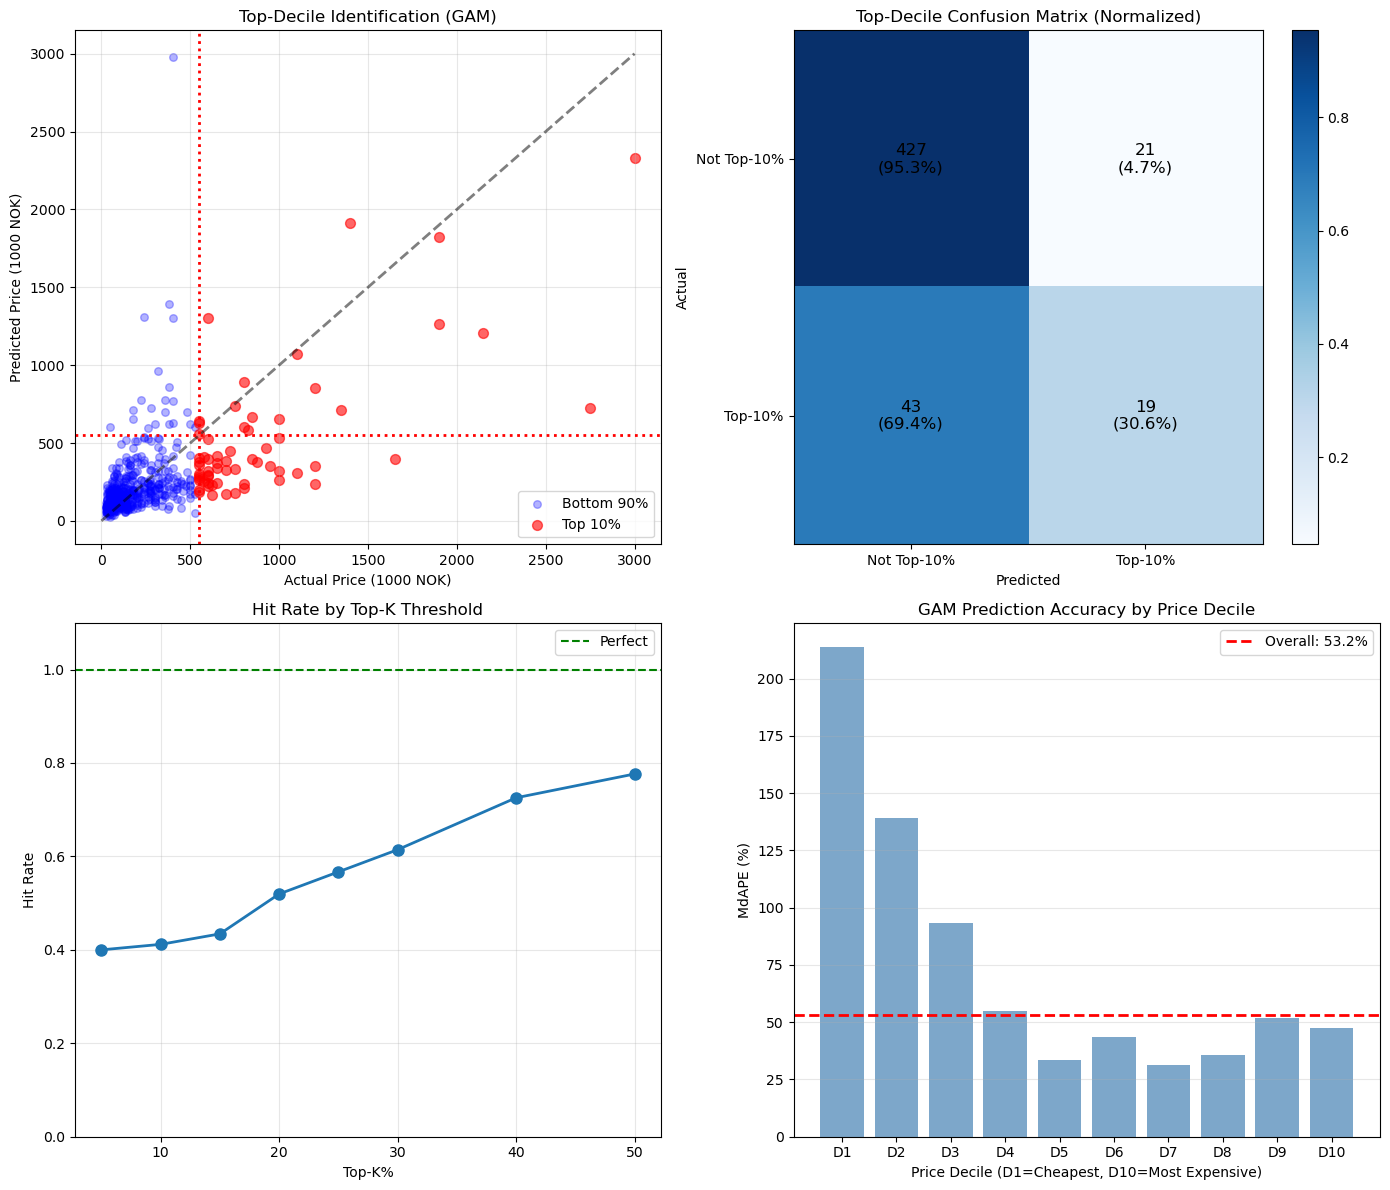

  ✓ Saved: gam_top_decile_analysis.png

[EXPORTING SUMMARY]
  ✓ Saved: gam_top_decile_metrics.xlsx

GAM TOP-DECILE ANALYSIS COMPLETE


In [27]:
# =========================================================
# TOP-DECILE ACCURACY METRICS
# =========================================================

import numpy as np
import pandas as pd

print("="*70)
print("TOP-DECILE ACCURACY ANALYSIS")
print("="*70)

# =========================================================
# 1. DEFINE TOP-DECILE THRESHOLDS
# =========================================================

# Training data
top_decile_threshold_train = np.percentile(y_train_price, 90)
print(f"\n[TOP-DECILE THRESHOLDS]")
print(f"  Training (90th percentile): {top_decile_threshold_train:>12,.0f} NOK")

# Test data
top_decile_threshold_test = np.percentile(y_test_price, 90)
print(f"  Test (90th percentile):     {top_decile_threshold_test:>12,.0f} NOK")

# =========================================================
# 2. IDENTIFY TOP-DECILE HORSES
# =========================================================

# Actual top-decile (ground truth)
actual_top_decile_train = y_train_price >= top_decile_threshold_train
actual_top_decile_test = y_test_price >= top_decile_threshold_test

# Predicted top-decile (based on model)
pred_top_decile_train = pred_train_price >= top_decile_threshold_train
pred_top_decile_test = pred_test_price >= top_decile_threshold_test

print(f"\n[TOP-DECILE COUNTS]")
print(f"  Training: {actual_top_decile_train.sum()} actual, {pred_top_decile_train.sum()} predicted")
print(f"  Test:     {actual_top_decile_test.sum()} actual, {pred_top_decile_test.sum()} predicted")

# =========================================================
# 3. PRECISION AND RECALL
# =========================================================

from sklearn.metrics import precision_score, recall_score, f1_score

print(f"\n[TOP-DECILE CLASSIFICATION METRICS]")

# Training
precision_train = precision_score(actual_top_decile_train, pred_top_decile_train)
recall_train = recall_score(actual_top_decile_train, pred_top_decile_train)
f1_train = f1_score(actual_top_decile_train, pred_top_decile_train)

print(f"\n  Training:")
print(f"    Precision: {precision_train:.3f}  (Of predicted top-10%, {precision_train*100:.1f}% are actually top-10%)")
print(f"    Recall:    {recall_train:.3f}  (Of actual top-10%, {recall_train*100:.1f}% were identified)")
print(f"    F1-Score:  {f1_train:.3f}")

# Test
precision_test = precision_score(actual_top_decile_test, pred_top_decile_test)
recall_test = recall_score(actual_top_decile_test, pred_top_decile_test)
f1_test = f1_score(actual_top_decile_test, pred_top_decile_test)

print(f"\n  Test:")
print(f"    Precision: {precision_test:.3f}  (Of predicted top-10%, {precision_test*100:.1f}% are actually top-10%)")
print(f"    Recall:    {recall_test:.3f}  (Of actual top-10%, {recall_test*100:.1f}% were identified)")
print(f"    F1-Score:  {f1_test:.3f}")

# =========================================================
# 4. CONFUSION MATRIX FOR TOP-DECILE
# =========================================================

from sklearn.metrics import confusion_matrix

print(f"\n[TOP-DECILE CONFUSION MATRIX - Test Set]")

cm = confusion_matrix(actual_top_decile_test, pred_top_decile_test)

print(f"\n                    Predicted")
print(f"                 Not Top-10%  Top-10%")
print(f"Actual Not Top   {cm[0,0]:>11}  {cm[0,1]:>8}")
print(f"Actual Top-10%   {cm[1,0]:>11}  {cm[1,1]:>8}")

# Calculate rates
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Positives (TP):  {tp:>4}  (Correctly identified as top-10%)")
print(f"  False Positives (FP): {fp:>4}  (Predicted top-10% but not)")
print(f"  True Negatives (TN):  {tn:>4}  (Correctly identified as not top-10%)")
print(f"  False Negatives (FN): {fn:>4}  (Missed actual top-10%)")

# =========================================================
# 5. TOP-DECILE SPECIFIC ERROR METRICS
# =========================================================

print(f"\n[ERROR METRICS FOR TOP-DECILE HORSES]")

# Test set - only top-decile horses
top_decile_mask_test = actual_top_decile_test
if top_decile_mask_test.sum() > 0:
    
    # Price errors for top-decile
    actual_top = y_test_price[top_decile_mask_test]
    pred_top = pred_test_price[top_decile_mask_test]
    
    mape_top = np.mean(np.abs((actual_top - pred_top) / actual_top)) * 100
    mdape_top = np.median(np.abs((actual_top - pred_top) / actual_top)) * 100
    rmse_top = np.sqrt(np.mean((actual_top - pred_top)**2))
    mae_top = np.mean(np.abs(actual_top - pred_top))
    mean_error_top = np.mean(actual_top - pred_top)
    
    print(f"\n  Test Set - Top-Decile Only (n={top_decile_mask_test.sum()}):")
    print(f"    MAPE:        {mape_top:.1f}%")
    print(f"    MdAPE:       {mdape_top:.1f}%")
    print(f"    RMSE:        {rmse_top:,.0f} NOK")
    print(f"    MAE:         {mae_top:,.0f} NOK")
    print(f"    Mean Error:  {mean_error_top:+,.0f} NOK")
    
    # Compare to overall test set
    mape_overall = np.mean(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100
    mdape_overall = np.median(np.abs((y_test_price - pred_test_price) / y_test_price)) * 100
    
    print(f"\n  Comparison to Overall Test Set:")
    print(f"    Top-10% MdAPE:  {mdape_top:.1f}%")
    print(f"    Overall MdAPE:  {mdape_overall:.1f}%")
    print(f"    Difference:     {mdape_top - mdape_overall:+.1f}%")
    
    if mdape_top < mdape_overall:
        print(f"    ✓ Model is MORE accurate for expensive horses")
    else:
        print(f"    ⚠ Model is LESS accurate for expensive horses")

# =========================================================
# 6. HIT RATE ANALYSIS
# =========================================================

print(f"\n[HIT RATE ANALYSIS]")
print("  (If you bid on predicted top-10%, what do you get?)")

# Get top N predictions
n_top = actual_top_decile_test.sum()  # Number of actual top-decile horses

# Sort by predicted price
test_indices = np.argsort(pred_test_price)[::-1]  # Descending order
top_n_predicted = test_indices[:n_top]

# How many are actually in top-decile?
hits = actual_top_decile_test[top_n_predicted].sum()
hit_rate = hits / n_top

print(f"\n  Strategy: Bid on top {n_top} horses (by predicted price)")
print(f"  Result:   {hits} out of {n_top} are actually top-10%")
print(f"  Hit Rate: {hit_rate:.1%}")

# Average price of horses we'd bid on
avg_actual_price_bid = y_test_price[top_n_predicted].mean()
avg_pred_price_bid = pred_test_price[top_n_predicted].mean()

print(f"\n  Horses we'd bid on:")
print(f"    Avg predicted price: {avg_pred_price_bid:>12,.0f} NOK")
print(f"    Avg actual price:    {avg_actual_price_bid:>12,.0f} NOK")
print(f"    Difference:          {avg_actual_price_bid - avg_pred_price_bid:>12,.0f} NOK")

# =========================================================
# 7. RANK CORRELATION
# =========================================================

from scipy.stats import spearmanr, kendalltau

print(f"\n[RANK CORRELATION]")
print("  (How well does model rank horses from cheap to expensive?)")

spearman_corr, spearman_p = spearmanr(y_test_price, pred_test_price)
kendall_corr, kendall_p = kendalltau(y_test_price, pred_test_price)

print(f"\n  Spearman Correlation: {spearman_corr:.4f} (p={spearman_p:.4e})")
print(f"  Kendall Tau:          {kendall_corr:.4f} (p={kendall_p:.4e})")

if spearman_corr > 0.7:
    print(f"  ✓ Excellent ranking ability")
elif spearman_corr > 0.5:
    print(f"  ~ Good ranking ability")
else:
    print(f"  ⚠ Moderate ranking ability")

# =========================================================
# 8. TOP-K ACCURACY (VARYING K)
# =========================================================

print(f"\n[TOP-K ACCURACY FOR DIFFERENT K VALUES]")
print(f"{'Top-K':<10} {'Actual in K':<15} {'Hit Rate':<12} {'Precision'}")
print(f"{'-'*10} {'-'*15} {'-'*12} {'-'*12}")

for k_pct in [5, 10, 15, 20, 25]:
    k = int(len(y_test_price) * k_pct / 100)
    
    # Get top-k by prediction
    top_k_indices = np.argsort(pred_test_price)[::-1][:k]
    
    # Threshold for actual top-k
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
    
    # How many of predicted top-k are actually top-k?
    hits_k = actual_top_k[top_k_indices].sum()
    hit_rate_k = hits_k / k
    
    print(f"Top-{k_pct:>2}%    {hits_k:>5}/{k:<7}    {hit_rate_k:>11.1%}    {hit_rate_k:.3f}")

# =========================================================
# 9. VISUALIZATION
# =========================================================

print(f"\n[CREATING VISUALIZATIONS]")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Scatter with top-decile highlighted
ax1 = axes[0, 0]
# Regular horses
mask_regular = ~actual_top_decile_test
ax1.scatter(y_test_price[mask_regular]/1000, 
            pred_test_price[mask_regular]/1000,
            alpha=0.3, s=30, label='Bottom 90%', color='blue')
# Top-decile horses
ax1.scatter(y_test_price[actual_top_decile_test]/1000,
            pred_test_price[actual_top_decile_test]/1000,
            alpha=0.6, s=50, label='Top 10%', color='red')
# Perfect prediction line
max_price = y_test_price.max() / 1000
ax1.plot([0, max_price], [0, max_price], 'k--', lw=2, alpha=0.5)
# Threshold lines
ax1.axvline(x=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.axhline(y=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.set_xlabel('Actual Price (1000 NOK)')
ax1.set_ylabel('Predicted Price (1000 NOK)')
ax1.set_title('Top-Decile Identification (GAM)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap
ax2 = axes[0, 1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax2.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_yticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Top-Decile Confusion Matrix (Normalized)')
# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                       ha="center", va="center", color="black", fontsize=12)
plt.colorbar(im, ax=ax2)

# Plot 3: Top-K Accuracy Curve
ax3 = axes[1, 0]
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
hit_rates = []
for k_pct in k_values:
    k = int(len(y_test_price) * k_pct / 100)
    top_k_indices = np.argsort(pred_test_price)[::-1][:k]
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
    hits_k = actual_top_k[top_k_indices].sum()
    hit_rates.append(hits_k / k)

ax3.plot(k_values, hit_rates, marker='o', linewidth=2, markersize=8)
ax3.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax3.set_xlabel('Top-K%')
ax3.set_ylabel('Hit Rate')
ax3.set_title('Hit Rate by Top-K Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# Plot 4: Error by Price Decile
ax4 = axes[1, 1]
decile_labels = []
decile_mdapes = []
for i in range(10):
    lower = np.percentile(y_test_price, i*10)
    upper = np.percentile(y_test_price, (i+1)*10)
    mask = (y_test_price >= lower) & (y_test_price < upper)
    if mask.sum() > 0:
        apes = np.abs((y_test_price[mask] - pred_test_price[mask]) / y_test_price[mask]) * 100
        decile_mdapes.append(np.median(apes))
        decile_labels.append(f'D{i+1}')

ax4.bar(range(len(decile_labels)), decile_mdapes, color='steelblue', alpha=0.7)
ax4.axhline(y=mdape_overall, color='red', linestyle='--', lw=2, label=f'Overall: {mdape_overall:.1f}%')
ax4.set_xlabel('Price Decile (D1=Cheapest, D10=Most Expensive)')
ax4.set_ylabel('MdAPE (%)')
ax4.set_title('GAM Prediction Accuracy by Price Decile')
ax4.set_xticks(range(len(decile_labels)))
ax4.set_xticklabels(decile_labels)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('gam_top_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✓ Saved: gam_top_decile_analysis.png")

# =========================================================
# 10. EXPORT SUMMARY
# =========================================================

print(f"\n[EXPORTING SUMMARY]")

top_decile_summary = pd.DataFrame({
    'Metric': [
        'Top-Decile Threshold',
        'Precision',
        'Recall',
        'F1-Score',
        'Hit Rate',
        'Top-Decile MdAPE',
        'Overall MdAPE',
        'Spearman Correlation',
    ],
    'Test': [
        f'{top_decile_threshold_test:,.0f} NOK',
        f'{precision_test:.3f}',
        f'{recall_test:.3f}',
        f'{f1_test:.3f}',
        f'{hit_rate:.1%}',
        f'{mdape_top:.1f}%',
        f'{mdape_overall:.1f}%',
        f'{spearman_corr:.4f}',
    ]
})

top_decile_summary.to_excel('gam_top_decile_metrics.xlsx', index=False)
print("  ✓ Saved: gam_top_decile_metrics.xlsx")

print("\n" + "="*70)
print("GAM TOP-DECILE ANALYSIS COMPLETE")
print("="*70)

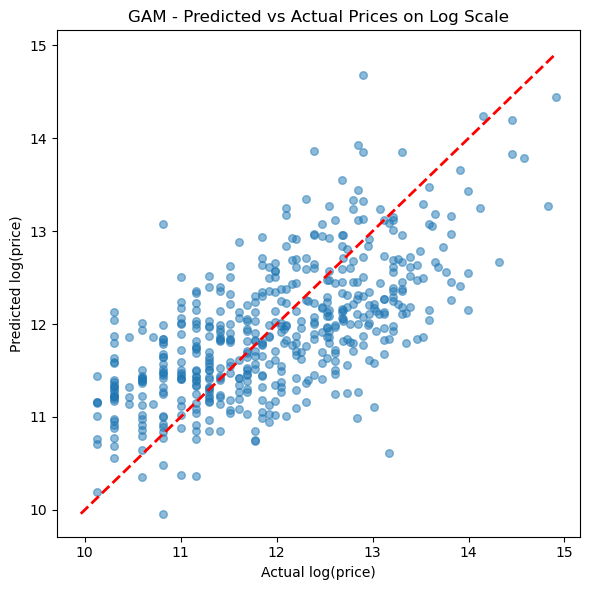

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(y_test, pred_test, alpha=0.5, s=30)

# 45-degree reference line
min_val = min(y_test.min(), pred_test.min())
max_val = max(y_test.max(), pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual log(price)")
plt.ylabel("Predicted log(price)")
plt.title("GAM - Predicted vs Actual Prices on Log Scale")
plt.savefig('GAM_predicted vs Actual prices.svg', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

NDCG RANKING METRIC

[NDCG — PRICE SCALE RELEVANCE]
  K                 n       NDCG
  ------------ ------ ----------
  Top 10%          51     0.6392
  Top 20%         102     0.6875
  Top 50%         255     0.7811
  Full            510     0.8509

[NDCG — LOG SCALE RELEVANCE]
  K                 n       NDCG
  ------------ ------ ----------
  Top 10%          51     0.9520
  Top 20%         102     0.9591
  Top 50%         255     0.9735
  Full            510     0.9925

[INTERPRETATION]
  NDCG@Full = 0.8509: Moderate overall ranking
  NDCG@10%  = 0.6392: Moderate at identifying top horses

  Spearman ρ = 0.6554 (p = 6.62e-64) for reference

CALIBRATION ANALYSIS BY DECILE

[CALIBRATION TABLE — MEANS BY PREDICTED DECILE]
  Decile    n   Act log  Pred log   Δ log      Act NOK     Pred NOK      Δ%
  ------ ---- --------- --------- ------- ------------ ------------ -------
       1   51    11.056    10.822  -0.234       84,314       64,181  -23.9%
       2   51    11.215    11.205  -0.0

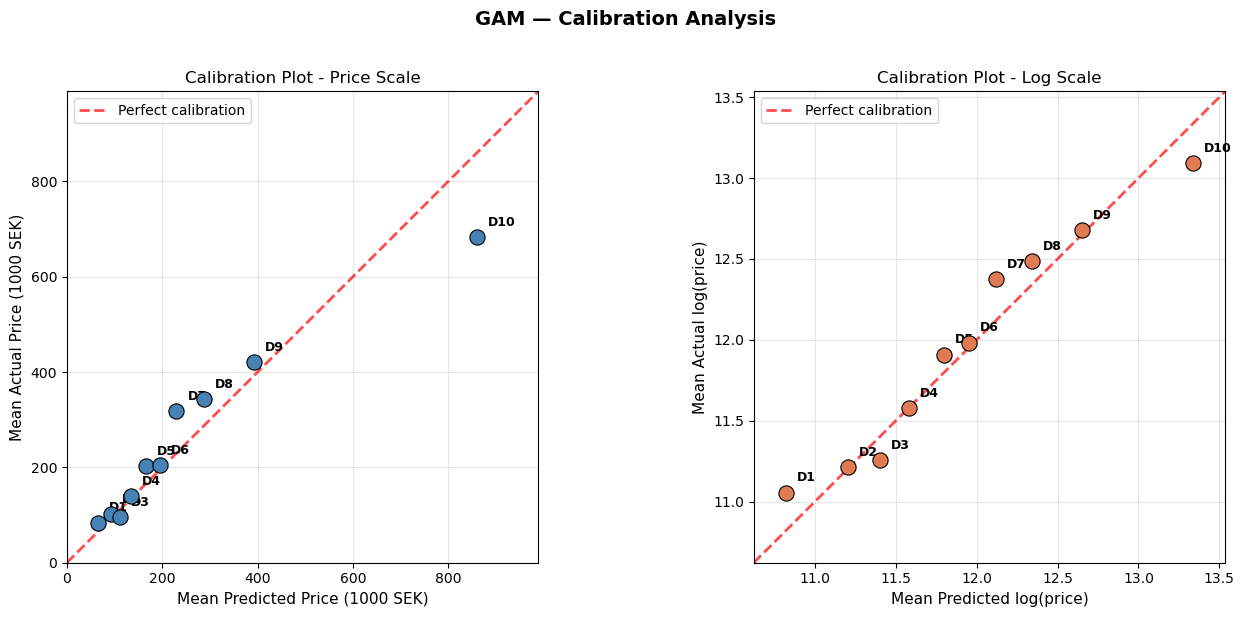


✓ Saved: gam_calibration_plot.svg


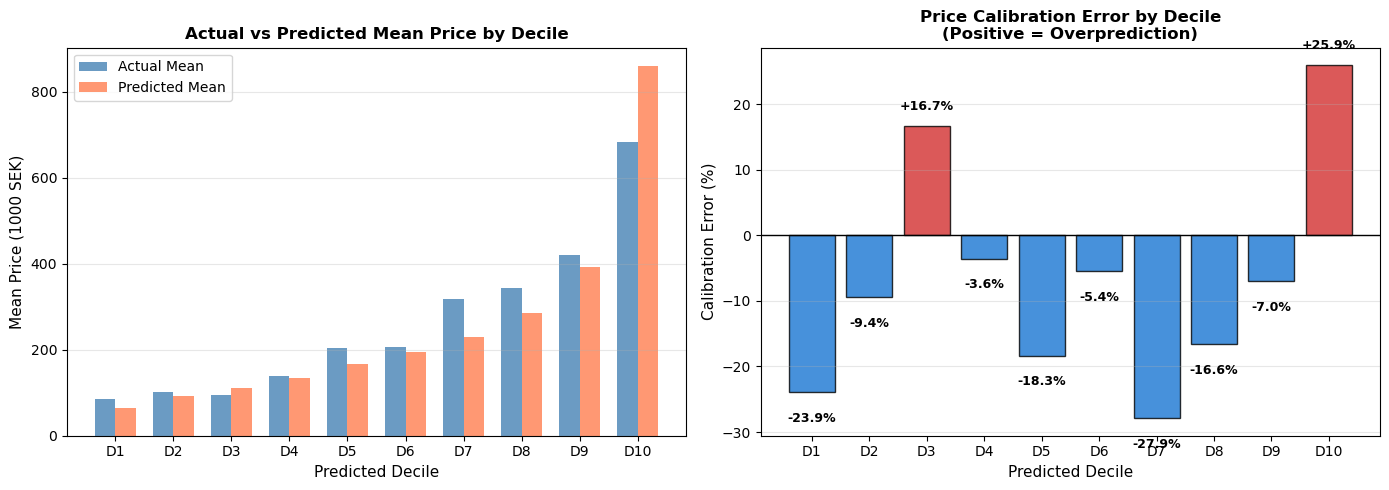

✓ Saved: gam_calibration_bars.svg
✓ Saved: gam_ndcg_metrics.xlsx
✓ Saved: gam_calibration_table.xlsx

NDCG & CALIBRATION ANALYSIS COMPLETE


In [29]:
# =========================================================
# NDCG RANKING METRIC & CALIBRATION PLOTS (UPDATED)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("=" * 70)
print("NDCG RANKING METRIC")
print("=" * 70)

# ---------------------------------------------------------
# A) NDCG CALCULATION
# ---------------------------------------------------------

def dcg_at_k(relevance, k):
    """Discounted Cumulative Gain at position k."""
    relevance = np.array(relevance[:k], dtype=float)
    positions = np.arange(1, len(relevance) + 1)
    return np.sum(relevance / np.log2(positions + 1))


def ndcg_at_k(y_true, y_pred, k):
    """
    NDCG@k: Sort items by predicted score, evaluate
    ranking quality using actual values as relevance.
    """
    pred_order = np.argsort(y_pred)[::-1]
    actual_ranked_by_pred = y_true[pred_order]

    ideal_order = np.argsort(y_true)[::-1]
    ideal_relevance = y_true[ideal_order]

    dcg = dcg_at_k(actual_ranked_by_pred, k)
    idcg = dcg_at_k(ideal_relevance, k)

    return dcg / idcg if idcg > 0 else 0.0


# --- Compute NDCG at multiple K values ---
n_test = len(y_test)

y_test_price_arr = np.exp(y_test.values)
pred_test_price_arr = pred_test_price
y_test_log_arr = y_test.values
pred_test_log_arr = pred_test

k_configs = [
    ("Top 10%", max(1, int(n_test * 0.10))),
    ("Top 20%", max(1, int(n_test * 0.20))),
    ("Top 50%", max(1, int(n_test * 0.50))),
    ("Full",    n_test),
]

print(f"\n[NDCG — PRICE SCALE RELEVANCE]")
print(f"  {'K':<12} {'n':>6} {'NDCG':>10}")
print(f"  {'-'*12} {'-'*6} {'-'*10}")

ndcg_results = []
for label, k in k_configs:
    ndcg = ndcg_at_k(y_test_price_arr, pred_test_price_arr, k)
    ndcg_results.append({"K": label, "n": k, "NDCG": ndcg})
    print(f"  {label:<12} {k:>6} {ndcg:>10.4f}")

print(f"\n[NDCG — LOG SCALE RELEVANCE]")
print(f"  {'K':<12} {'n':>6} {'NDCG':>10}")
print(f"  {'-'*12} {'-'*6} {'-'*10}")

for label, k in k_configs:
    ndcg = ndcg_at_k(y_test_log_arr, pred_test_log_arr, k)
    print(f"  {label:<12} {k:>6} {ndcg:>10.4f}")

ndcg_full = ndcg_results[-1]["NDCG"]
ndcg_top10 = ndcg_results[0]["NDCG"]

print(f"\n[INTERPRETATION]")
if ndcg_full > 0.95:
    print(f"  NDCG@Full = {ndcg_full:.4f}: Excellent overall ranking")
elif ndcg_full > 0.90:
    print(f"  NDCG@Full = {ndcg_full:.4f}: Good overall ranking")
else:
    print(f"  NDCG@Full = {ndcg_full:.4f}: Moderate overall ranking")

if ndcg_top10 > 0.90:
    print(f"  NDCG@10%  = {ndcg_top10:.4f}: Excellent at identifying top horses")
elif ndcg_top10 > 0.80:
    print(f"  NDCG@10%  = {ndcg_top10:.4f}: Good at identifying top horses")
else:
    print(f"  NDCG@10%  = {ndcg_top10:.4f}: Moderate at identifying top horses")

spearman_corr, spearman_p = spearmanr(y_test_price_arr, pred_test_price_arr)
print(f"\n  Spearman ρ = {spearman_corr:.4f} (p = {spearman_p:.2e}) for reference")


# =========================================================
# B) CALIBRATION ANALYSIS BY DECILE
# =========================================================

print(f"\n{'=' * 70}")
print("CALIBRATION ANALYSIS BY DECILE")
print(f"{'=' * 70}")

# ---------------------------------------------------------
# Build decile table
# ---------------------------------------------------------
pred_deciles = pd.qcut(pred_test, q=10, labels=False, duplicates="drop") + 1

cal_data = pd.DataFrame({
    "actual_log": y_test.values,
    "pred_log": pred_test,
    "actual_price": y_test_price_arr,
    "pred_price": pred_test_price_arr,
    "decile": pred_deciles,
})

cal_table = cal_data.groupby("decile").agg(
    n=("actual_log", "size"),
    actual_log_mean=("actual_log", "mean"),
    pred_log_mean=("pred_log", "mean"),
    actual_price_mean=("actual_price", "mean"),
    pred_price_mean=("pred_price", "mean"),
    actual_price_median=("actual_price", "median"),
    pred_price_median=("pred_price", "median"),
).reset_index()

cal_table["log_error"] = cal_table["pred_log_mean"] - cal_table["actual_log_mean"]
cal_table["price_error"] = cal_table["pred_price_mean"] - cal_table["actual_price_mean"]
cal_table["price_error_pct"] = (
    (cal_table["pred_price_mean"] - cal_table["actual_price_mean"])
    / cal_table["actual_price_mean"] * 100
)

print(f"\n[CALIBRATION TABLE — MEANS BY PREDICTED DECILE]")
print(f"  {'Decile':>6} {'n':>4} {'Act log':>9} {'Pred log':>9} "
      f"{'Δ log':>7} {'Act NOK':>12} {'Pred NOK':>12} {'Δ%':>7}")
print(f"  {'-'*6} {'-'*4} {'-'*9} {'-'*9} {'-'*7} {'-'*12} {'-'*12} {'-'*7}")

for _, row in cal_table.iterrows():
    print(f"  {int(row['decile']):>6} {int(row['n']):>4} "
          f"{row['actual_log_mean']:>9.3f} {row['pred_log_mean']:>9.3f} "
          f"{row['log_error']:>+7.3f} "
          f"{row['actual_price_mean']:>12,.0f} {row['pred_price_mean']:>12,.0f} "
          f"{row['price_error_pct']:>+6.1f}%")

mae_cal_log = np.mean(np.abs(cal_table["log_error"]))
mae_cal_pct = np.mean(np.abs(cal_table["price_error_pct"]))
print(f"\n  Mean Absolute Calibration Error (log):   {mae_cal_log:.4f}")
print(f"  Mean Absolute Calibration Error (price): {mae_cal_pct:.1f}%")


# ---------------------------------------------------------
# CALIBRATION BIAS BY DECILE GROUP (D1-D3, D4-D7, D8-D10)
# ---------------------------------------------------------

print(f"\n{'=' * 70}")
print("CALIBRATION BIAS BY DECILE GROUP")
print(f"{'=' * 70}")

def decile_group(d):
    if d <= 3:
        return "D1–D3 (low)"
    elif d <= 7:
        return "D4–D7 (mid)"
    else:
        return "D8–D10 (high)"

cal_data["decile_group"] = cal_data["decile"].apply(decile_group)

group_order = ["D1–D3 (low)", "D4–D7 (mid)", "D8–D10 (high)"]

bias_table = []
for group in group_order:
    mask = cal_data["decile_group"] == group
    subset = cal_data[mask]
    
    avg_bias_log = (subset["pred_log"] - subset["actual_log"]).mean()
    avg_bias_price = (subset["pred_price"] - subset["actual_price"]).mean()
    n = len(subset)
    
    bias_table.append({
        "Decile Group": group,
        "n": n,
        "Average Bias (log scale)": avg_bias_log,
        "Average Bias (Price Scale)": avg_bias_price,
    })

bias_df = pd.DataFrame(bias_table)

print(f"\n  {'Decile Group':<18} {'n':>5} {'Avg Bias (log)':>16} {'Avg Bias (Price)':>18}")
print(f"  {'-'*18} {'-'*5} {'-'*16} {'-'*18}")
for _, row in bias_df.iterrows():
    print(f"  {row['Decile Group']:<18} {int(row['n']):>5} "
          f"{row['Average Bias (log scale)']:>+16.3f} "
          f"{row['Average Bias (Price Scale)']:>+18,.0f}")

# Save bias table
bias_df.to_excel("gam_calibration_bias_by_group.xlsx", index=False)
print(f"\n✓ Saved: gam_calibration_bias_by_group.xlsx")


# ---------------------------------------------------------
# CALIBRATION PLOTS (Price left, Log right, matching style)
# ---------------------------------------------------------

DOT_COLOR = "#E07B54"  # coral/orange to match BHM style

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GAM — Calibration Analysis", fontsize=14, fontweight="bold", y=1.02)

# --- LEFT: Price scale ---
ax1 = axes[0]

all_price = np.concatenate([cal_table["actual_price_mean"], cal_table["pred_price_mean"]])
price_max = all_price.max() * 1.15 / 1000
price_min = 0

ax1.plot([price_min, price_max], [price_min, price_max], "r--", lw=2, alpha=0.7,
         label="Perfect calibration")

ax1.scatter(cal_table["pred_price_mean"] / 1000,
            cal_table["actual_price_mean"] / 1000,
            s=120, c='steelblue', edgecolors="black", linewidths=0.8, zorder=5)

for _, row in cal_table.iterrows():
    ax1.annotate(f"D{int(row['decile'])}",
                 (row["pred_price_mean"] / 1000, row["actual_price_mean"] / 1000),
                 textcoords="offset points", xytext=(8, 8),
                 fontsize=9, fontweight="bold")

ax1.set_xlabel("Mean Predicted Price (1000 SEK)", fontsize=11)
ax1.set_ylabel("Mean Actual Price (1000 SEK)", fontsize=11)
ax1.set_title("Calibration Plot - Price Scale", fontsize=12)
ax1.legend(fontsize=10, loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(price_min, price_max)
ax1.set_ylim(price_min, price_max)
ax1.set_aspect("equal")

# --- RIGHT: Log scale ---
ax2 = axes[1]

all_log = np.concatenate([cal_table["actual_log_mean"], cal_table["pred_log_mean"]])
log_min = all_log.min() - 0.2
log_max = all_log.max() + 0.2

ax2.plot([log_min, log_max], [log_min, log_max], "r--", lw=2, alpha=0.7,
         label="Perfect calibration")

ax2.scatter(cal_table["pred_log_mean"],
            cal_table["actual_log_mean"],
            s=120, c=DOT_COLOR, edgecolors="black", linewidths=0.8, zorder=5)

for _, row in cal_table.iterrows():
    ax2.annotate(f"D{int(row['decile'])}",
                 (row["pred_log_mean"], row["actual_log_mean"]),
                 textcoords="offset points", xytext=(8, 8),
                 fontsize=9, fontweight="bold")

ax2.set_xlabel("Mean Predicted log(price)", fontsize=11)
ax2.set_ylabel("Mean Actual log(price)", fontsize=11)
ax2.set_title("Calibration Plot - Log Scale", fontsize=12)
ax2.legend(fontsize=10, loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(log_min, log_max)
ax2.set_ylim(log_min, log_max)
ax2.set_aspect("equal")

plt.tight_layout()
plt.savefig("gam_calibration_plot.svg", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Saved: gam_calibration_plot.svg")


# ---------------------------------------------------------
# Bar chart: Actual vs Predicted by decile (price)
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Mean prices side by side ---
ax3 = axes[0]
x = np.arange(len(cal_table))
width = 0.35

bars1 = ax3.bar(x - width/2, cal_table["actual_price_mean"] / 1000, width,
                label="Actual Mean", color="steelblue", alpha=0.8)
bars2 = ax3.bar(x + width/2, cal_table["pred_price_mean"] / 1000, width,
                label="Predicted Mean", color="coral", alpha=0.8)

ax3.set_xlabel("Predicted Decile", fontsize=11)
ax3.set_ylabel("Mean Price (1000 SEK)", fontsize=11)
ax3.set_title("Actual vs Predicted Mean Price by Decile", fontsize=12, fontweight="bold")
ax3.set_xticks(x)
ax3.set_xticklabels([f"D{int(d)}" for d in cal_table["decile"]])
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis="y")

# --- Right: Calibration error % by decile ---
ax4 = axes[1]
colors = ["#d32f2f" if e > 0 else "#1976d2" for e in cal_table["price_error_pct"]]
ax4.bar(x, cal_table["price_error_pct"], color=colors, alpha=0.8, edgecolor="black")
ax4.axhline(y=0, color="black", linewidth=1)
ax4.set_xlabel("Predicted Decile", fontsize=11)
ax4.set_ylabel("Calibration Error (%)", fontsize=11)
ax4.set_title("Price Calibration Error by Decile\n"
              "(Positive = Overprediction)", fontsize=12, fontweight="bold")
ax4.set_xticks(x)
ax4.set_xticklabels([f"D{int(d)}" for d in cal_table["decile"]])
ax4.grid(True, alpha=0.3, axis="y")

for i, val in enumerate(cal_table["price_error_pct"]):
    ax4.text(i, val + (2 if val >= 0 else -3), f"{val:+.1f}%",
             ha="center", va="bottom" if val >= 0 else "top", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("gam_calibration_bars.svg", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: gam_calibration_bars.svg")


# ---------------------------------------------------------
# Export
# ---------------------------------------------------------
ndcg_df = pd.DataFrame(ndcg_results)
ndcg_df.to_excel("gam_ndcg_metrics.xlsx", index=False)
print(f"✓ Saved: gam_ndcg_metrics.xlsx")

cal_table.to_excel("gam_calibration_table.xlsx", index=False)
print(f"✓ Saved: gam_calibration_table.xlsx")

print(f"\n{'=' * 70}")
print("NDCG & CALIBRATION ANALYSIS COMPLETE")
print(f"{'=' * 70}")